# COMP9444 26T2 - Insect pest species identification (001)

**Date:** 21/07/2026  
**Class:** T13B  
**Team:** Neuromancer  

### **Environment Setup**

In [55]:
#%pip install -q numpy pandas matplotlib seaborn scipy scikit-learn scikit-image imbalanced-learn pillow tqdm joblib ipython torch torchvision torchinfo xgboost

In [56]:
# ============================================================
# Standard Library & Utilities
# ============================================================
import os
import sys
import time
import json
import random
import joblib
import subprocess
from pathlib import Path
from collections import Counter
from concurrent.futures import ThreadPoolExecutor

# ============================================================
# Data Science & Machine Learning
# ============================================================
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

from PIL import Image, ImageFile
from IPython.display import display
from tqdm.auto import tqdm

from skimage.color import rgb2gray, rgb2hsv
from skimage.feature import hog

from sklearn.preprocessing import StandardScaler, Normalizer, label_binarize
from sklearn.decomposition import PCA
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

from imblearn.metrics import geometric_mean_score
from scipy.special import softmax
from xgboost import XGBClassifier

ImageFile.LOAD_TRUNCATED_IMAGES = True

# ============================================================
# PyTorch & Deep Learning
# ============================================================
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.checkpoint as cp

from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchinfo import summary

# ============================================================
# Setup
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

SEED = 9444

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

print("Device:", device)
print("PyTorch:", torch.__version__)
print("Python:", sys.executable)
print("Working directory:", Path.cwd())

GPU: NVIDIA GeForce RTX 5070 Laptop GPU
CUDA: 12.8
Device: cuda
PyTorch: 2.11.0+cu128
Python: c:\Users\Schhilling\Desktop\COMP9444_Project\.venv\Scripts\python.exe
Working directory: c:\Users\Schhilling\Desktop\COMP9444_Project


In [57]:
PROJECT_DIR = Path(
    r"C:\Users\Schhilling\Desktop\COMP9444_Project"
)

DATASET_DIR = PROJECT_DIR / "Dataset"
IMAGE_DIR = DATASET_DIR / "images"

TRAIN_FILE = DATASET_DIR / "train.txt"
VAL_FILE = DATASET_DIR / "val.txt"
TEST_FILE = DATASET_DIR / "test.txt"
CLASSES_FILE = DATASET_DIR / "classes.txt"

print("Project directory:", PROJECT_DIR)
print("Dataset directory:", DATASET_DIR)
print("Output directory:", Path.cwd())

Project directory: C:\Users\Schhilling\Desktop\COMP9444_Project
Dataset directory: C:\Users\Schhilling\Desktop\COMP9444_Project\Dataset
Output directory: c:\Users\Schhilling\Desktop\COMP9444_Project


## **1. Motivation**

The aim of this project is to analyse the IP102 dataset and compare the performance of traditional machine learning and deep learning models for image classification. The models used include SVM, KNN, ResNet-50, and InsecNet - a custom CNN based on DenseNet121 with some architectural modifications.

The primary motivation is to evaluate how different classification approaches perform on the same dataset and identify the model that provides the highest overall performance based on the chosen metrics. By comparing these models, the project aims to determine which approach is most suitable for accurate and reliable image classification. If applied in agriculture, the findings could support tasks such as crop monitoring and early disease detection, helping improve decision-making and reduce potential crop losses.

## **2. Data Source**

This project uses the IP102 dataset, a publicly available benchmark for insect pest image classification. The dataset contains images of insect pest species that affect eight different crop types, including rice, corn, wheat, beet, alfalfa, citrus, mango, and vitis.

The images were collected from multiple online sources, including search engines, agricultural websites, and video clips. After collection, the images were filtered and professionally annotated by agricultural experts to ensure accurate and reliable class labels. The dataset includes insects at different life stages (egg, larva, pupa, and adult) and images captured under varying viewpoints, lighting conditions, and background complexity, making it well suited for evaluating machine learning and deep learning models for insect pest classification.

## **3. Exploratory Data Analysis (EDA)**

The IP102 dataset contains 75,222 images across 102 insect pest classes. It is divided into 45,095 training, 7,508 validation, and 22,619 testing images, with the data split defined in three text files containing the image IDs. The images exhibit variations in size, lighting conditions, viewpoints, insect life stages, background complexity, and the presence of watermarks.

The dataset presents several challenges for image classification:

- **Class imbalance**: Some insect species contain significantly more samples than others, which may bias model performance towards majority classes.
- **Visual similarity**: Many insect species have similar appearances, while differences in life stages, occlusions, and cluttered backgrounds further increase the difficulty of accurate classification.

### **Data Loading**

In [58]:
# Load the txt files
train = pd.read_csv(TRAIN_FILE, sep=r"\s+", header=None, names=["file", "class"])
val   = pd.read_csv(VAL_FILE,   sep=r"\s+", header=None, names=["file", "class"])
test  = pd.read_csv(TEST_FILE,  sep=r"\s+", header=None, names=["file", "class"])

# Clean filenames and labels
for split in (train, val, test):
    split["file"] = split["file"].apply(lambda x: Path(x).name)
    split["class"] = split["class"].astype(int)

# Check missing values
check_nulls = pd.DataFrame({
    "Train Nulls": train.isnull().sum(),
    "Val Nulls": val.isnull().sum(),
    "Test Nulls": test.isnull().sum(),
})

print(check_nulls)

       Train Nulls  Val Nulls  Test Nulls
file             0          0           0
class            0          0           0


### **Dataset Split**
The dataset partitioning was verified to follow a split ratio of exactly 60/30/10 for the Training, Validation, and Testing sets respectively.

In [59]:
total_images = len(train) + len(val) + len(test)

print(f"Train: {len(train)}  images ({len(train) / total_images:.0%})")
print(f"Val  : {len(val)}   images ({len(val)    / total_images:.0%})")
print(f"Test : {len(test)}  images ({len(test)   / total_images:.0%})")
print("---------------------------")
print(f"Total: {total_images:,} images ({total_images / total_images:.0%})")

Train: 45095  images (60%)
Val  : 7508   images (10%)
Test : 22619  images (30%)
---------------------------
Total: 75,222 images (100%)


### **Class Distribution Analysis**
The distribution demonstrates the long-tailed nature of the dataset, where sample quantities vary considerably among the 102 insect categories.

In [60]:
# Build the distribution table
df = pd.DataFrame()

# Training
df['Train'] = train['class'].value_counts()
df['Tr %']  = train['class'].value_counts(normalize=True) * 100

# Validation
df['Val']   = val['class'].value_counts()
df['Val %'] = val['class'].value_counts(normalize=True) * 100

# Testing
df['Test'] = test['class'].value_counts()
df['Te %'] = test['class'].value_counts(normalize=True) * 100

# Sort by Class ID
df = df.sort_index()

# Print the table
print(df)
n_classes = len(df)
print(f"Total Unique Classes: {n_classes}")

       Train      Tr %  Val     Val %  Test      Te %
class                                                
0        669  1.483535  111  1.478423   335  1.481056
1        292  0.647522   48  0.639318   147  0.649896
2        156  0.345936   26  0.346297    79  0.349264
3        631  1.399268  106  1.411827   316  1.397056
4        302  0.669697   50  0.665956   152  0.672001
...      ...       ...  ...       ...   ...       ...
97       183  0.405810   30  0.399574    92  0.406738
98        55  0.121965   10  0.133191    28  0.123790
99       333  0.738441   55  0.732552   167  0.738317
100      274  0.607606   46  0.612680   138  0.610107
101     3444  7.637210  573  7.631859  1723  7.617490

[102 rows x 6 columns]
Total Unique Classes: 102


Largest Class : #101 (3444 samples)
Smallest Class: #72  (  42 samples)
---------------------------------------------------------
Number of classes : 102
Maximum samples   : 3444
Minimum samples   : 42
Mean samples      : 442.11
Median samples    : 289.00
Std deviation     : 582.87
Imbalance Ratio   : 82.00x (Majority is 82.00 times larger)



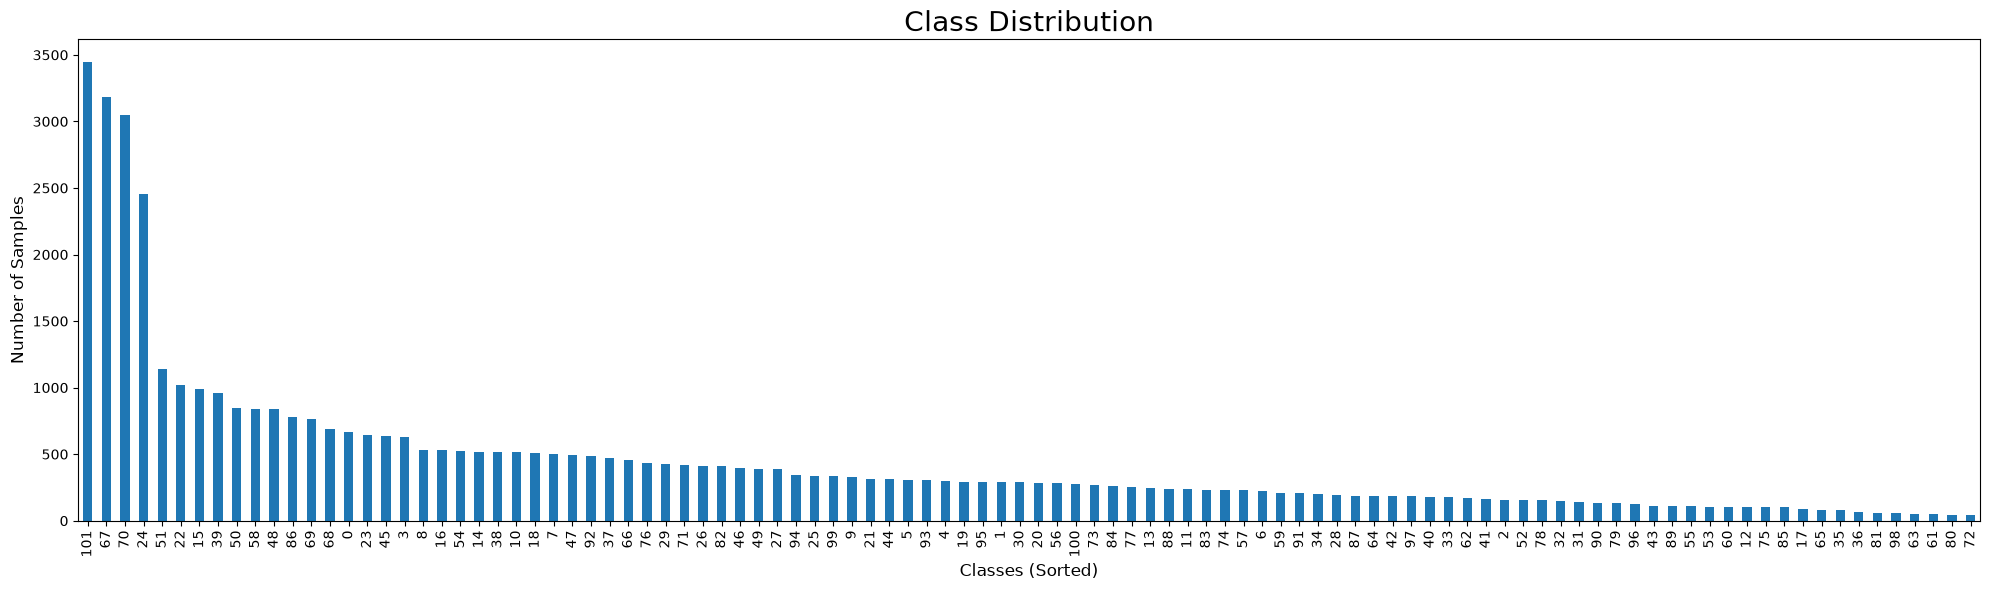

In [61]:
# Class distribution analysis
train_counts   = train['class'].value_counts()
majority_class = train_counts.index[0]
majority_count = train_counts.iloc[0]

minority_class = train_counts.index[-1]
minority_count = train_counts.iloc[-1]

imbalance_ratio = majority_count / minority_count

print(f"Largest Class : #{majority_class} ({majority_count} samples)")
print(f"Smallest Class: #{minority_class}  (  {minority_count} samples)")
print("---------------------------------------------------------")
print(f"Number of classes : {len(train_counts)}")
print(f"Maximum samples   : {train_counts.max()}")
print(f"Minimum samples   : {train_counts.min()}")
print(f"Mean samples      : {train_counts.mean():.2f}")
print(f"Median samples    : {train_counts.median():.2f}")
print(f"Std deviation     : {train_counts.std():.2f}")
print(f"Imbalance Ratio   : {imbalance_ratio:.2f}x (Majority is {imbalance_ratio:.2f} times larger)\n")

# Visualization
df['Train'].sort_values(ascending=False).plot(kind='bar', figsize=(20, 6))
plt.xticks(rotation=90, fontsize=10)
plt.title("Class Distribution", fontsize=20)
plt.ylabel("Number of Samples", fontsize=12)
plt.xlabel("Classes (Sorted)", fontsize=12)
plt.tight_layout()
plt.show()

### **Challenge: Class Imbalance**
A key challenge in the IP102 dataset is its severe class imbalance, where some insect pest classes contain significantly more images than others. This uneven distribution can negatively affect model performance:

- **Bias**: The model will naturally favor the majority classes just to get a higher overall score, essentially ignoring the rare classes.
- **Overfitting**: With only 42 samples in the smallest class, the model doesn't have enough examples to learn general features and will likely just memorize specific images.

Addressing class imbalance will be an important consideration when training and evaluating the classification models.

## **4. Data Preprocessing**
### **Data Augmentation**
To improve generalization, training images were augmented using random resized cropping, horizontal flipping, RandAugment, and random erasing. All images were resized to 224×224 and normalized, while validation and testing used only deterministic resizing, cropping, and normalization for consistent evaluation.

In [62]:
image_size = 224
normalize  = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# Training Pipeline (Heavy Data Augmentation)
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(image_size, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, value="random"),
])

# Testing Pipeline (NO random augmentations)
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

Example augmented images generated from the training pipeline are shown below:

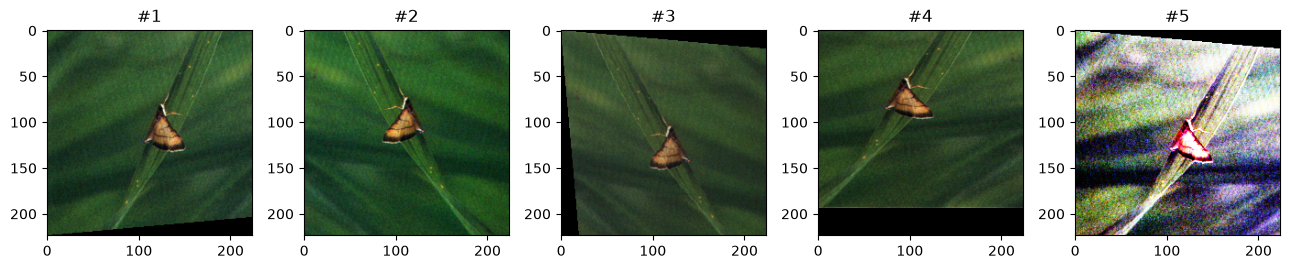

In [63]:
img_path = os.path.join(IMAGE_DIR, train['file'].iloc[420])
img = Image.open(img_path).convert('RGB')

# Sample transformation
vis_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=2, magnitude=9),
])

# Plot 5 random transformations
fig, axes = plt.subplots(1, 5, figsize=(13, 3))

for i in range(5):
    axes[i].imshow(vis_tf(img))
    axes[i].set_title(f"#{i+1}")

plt.tight_layout()
plt.show()

### **DataLoader**
A custom dataset was used to load images, labels, and transformations. DataLoaders were created for training, validation, and testing with a batch size of 32.

In [64]:
class IP102(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir    = img_dir
        self.transform  = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
         # Load image and convert to RGB
        img_name = os.path.join(self.img_dir, self.dataframe['file'].iloc[idx])
        with Image.open(img_name) as img:
            image = img.convert("RGB")

        # Get class label
        label = self.dataframe['class'].iloc[idx]

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        return image, label

# Build datasets
train_set = IP102(dataframe=train, img_dir=IMAGE_DIR, transform=train_tf)
val_set   = IP102(dataframe=val,   img_dir=IMAGE_DIR, transform=eval_tf)
test_set  = IP102(dataframe=test,  img_dir=IMAGE_DIR, transform=eval_tf)

# Create dataLoaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print("DataLoader Summary")
print("------------------")
print("Train:", len(train_loader), "(batches)")
print("Val  :", len(val_loader), " (batches)")
print("Test :", len(test_loader), " (batches)")

DataLoader Summary
------------------
Train: 1410 (batches)
Val  : 235  (batches)
Test : 707  (batches)


## **5. Models**

<h1 align="center" style="font-size: 2.0rem; margin-bottom: 1.5rem;">Method 1: SVM + KNN</h1>
<h2 align="center" style="font-size: 1.1rem; color: #555; margin-bottom: 1.5rem; font-style: italic;">by: Yuecheng Qin</h2>

### **Model Configuration**

In [65]:
FEATURE_SIZE = 64
PCA_COMPONENTS = 64
SVM_C = 1.0
KNN_K = 5
FEATURE_WORKERS = 4

MAX_TRAIN_PER_CLASS = 0 #use 100 or 200 to make a faster training process, use 0 in the final training

# Confirm that the group preprocessing has been executed
required_variables = {
    "train": train,
    "val": val,
    "test": test,
    "IMAGE_DIR": IMAGE_DIR,
    "CLASSES_FILE": CLASSES_FILE,
}
for variable_name, variable_value in (required_variables.items()):
    if variable_value is None:
        raise ValueError(f"{variable_name} has not been created.")
# Output directories
SVM_KNN_OUTPUT_DIR = (Path.cwd() / "svm_knn_outputs")
SVM_KNN_FIGURE_DIR = (SVM_KNN_OUTPUT_DIR / "figures")
SVM_KNN_CACHE_DIR = (SVM_KNN_OUTPUT_DIR / "cache")
SVM_KNN_MODEL_DIR = (SVM_KNN_OUTPUT_DIR / "models")

for directory in [
    SVM_KNN_OUTPUT_DIR,
    SVM_KNN_FIGURE_DIR,
    SVM_KNN_CACHE_DIR,
    SVM_KNN_MODEL_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True,)
    
configuration = pd.DataFrame([{
    "feature_size": FEATURE_SIZE,
    "pca_components": PCA_COMPONENTS,
    "svm_c": SVM_C,
    "knn_k": KNN_K,
    "feature_workers": FEATURE_WORKERS,
    "max_train_per_class": MAX_TRAIN_PER_CLASS,
    "seed": SEED,
}])

display(configuration.style.hide(axis="index"))

print("Project directory:", PROJECT_DIR)
print("Image directory  :", IMAGE_DIR)
print("Output directory :", SVM_KNN_OUTPUT_DIR)

feature_size,pca_components,svm_c,knn_k,feature_workers,max_train_per_class,seed
64,64,1.000000,5,4,0,9444


Project directory: C:\Users\Schhilling\Desktop\COMP9444_Project
Image directory  : C:\Users\Schhilling\Desktop\COMP9444_Project\Dataset\images
Output directory : c:\Users\Schhilling\Desktop\COMP9444_Project\svm_knn_outputs


### **Create Records and Load Class Names**

In [66]:
# Create a continuous label mapping
raw_train_labels = sorted(train["class"].unique().tolist())

label_map = {raw_label: new_label
    for new_label, raw_label in enumerate(raw_train_labels)}
NUM_CLASSES = len(raw_train_labels)

def dataframe_to_records(dataframe):
    #Convert the group DataFrame into: [(image_path, continuous_label), ...]
    output_records = []
    for filename, raw_label in zip(dataframe["file"], dataframe["class"],):
        if raw_label not in label_map:
            raise ValueError(f"Unknown class label: {raw_label}")
        output_records.append(
            (
                IMAGE_DIR / Path(filename).name,
                label_map[int(raw_label)],
            )
        )
    return output_records
records = {
    "train": dataframe_to_records(train),
    "val": dataframe_to_records(val),
    "test": dataframe_to_records(test),}

print("Train records:", len(records["train"]),)
print("Val   records:", len(records["val"]),)
print("Test  records:", len(records["test"]),)
print("Number of classes:", NUM_CLASSES,)

# Load IP102 class names
class_lines = [line.strip()
    for line in CLASSES_FILE.read_text(
        encoding="utf-8").splitlines()
    if line.strip()
]
class_names = []
for line in class_lines:
    parts = line.split(maxsplit=1)
    if (len(parts) == 2 and parts[0].isdigit()):
        class_names.append(parts[1])
    else:
        class_names.append(line)

print("Number of class names:", len(class_names),)
print("First five classes:", class_names[:5],)

Train records: 45095
Val   records: 7508
Test  records: 22619
Number of classes: 102
Number of class names: 102
First five classes: ['rice leaf roller', 'rice leaf caterpillar', 'paddy stem maggot', 'asiatic rice borer', 'yellow rice borer']


### **Training Sample Selection**

In [67]:
def limit_samples_per_class(samples, maximum_per_class,):
    if maximum_per_class <= 0:
        return list(samples)
    rng = np.random.default_rng(SEED)
    grouped_samples = {}
    for sample in samples:
        label = sample[1]
        grouped_samples.setdefault(label, [],).append(sample)
    selected_samples = []
    for label in sorted(grouped_samples):
        class_samples = grouped_samples[label]
        number_to_select = min(
            maximum_per_class,
            len(class_samples),)
        selected_indices = rng.choice(
            len(class_samples),
            size=number_to_select,
            replace=False,)
        selected_samples.extend([class_samples[index]
            for index in selected_indices])

    rng.shuffle(selected_samples)
    return selected_samples

selected_train_records = (
    limit_samples_per_class(
        records["train"],
        MAX_TRAIN_PER_CLASS,))
selected_labels = np.asarray(
    [
        label
        for _, label
        in selected_train_records
    ], dtype=np.int64, )
selected_counts = np.bincount(selected_labels, minlength=NUM_CLASSES,)
assert (np.count_nonzero(selected_counts) == NUM_CLASSES), "Some classes are missing."

if MAX_TRAIN_PER_CLASS > 0:
    assert (selected_counts.max() <= MAX_TRAIN_PER_CLASS)
print("Original training images:", len(records["train"]),)
print("Selected training images:", len(selected_train_records),)
print("Selected classes:", np.count_nonzero(selected_counts),)
print("Smallest selected class:", selected_counts.min(),)
print("Largest  selected class:", selected_counts.max(),)

Original training images: 45095
Selected training images: 45095
Selected classes: 102
Smallest selected class: 42
Largest  selected class: 3444


### **Feature Extraction Functions**

In [68]:
def load_image_with_retry(
    image_path,
    maximum_attempts=3,
    wait_seconds=1,
):
    last_error = None
    for attempt in range(1, maximum_attempts + 1,):
        try:
            with Image.open(image_path) as image:
                return (image.convert("RGB").copy())
        except OSError as error:
            last_error = error
            print(
                f"Image read error "
                f"({attempt}/{maximum_attempts}): "
                f"{image_path.name}"
            )

            time.sleep(wait_seconds)

    raise OSError(f"Failed to read {image_path}") from last_error

def extract_image_feature(image_path):
    image = load_image_with_retry(image_path)
    image = image.resize((FEATURE_SIZE, FEATURE_SIZE,))
    rgb = np.asarray(image, dtype=np.float32,) / 255.0
    # HOG shape features
    hog_feature = hog(
        rgb2gray(rgb),
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True,
    )
    # HSV colour histograms
    hsv = rgb2hsv(rgb)
    colour_feature = np.concatenate([
        np.histogram(
            hsv[..., channel],
            bins=16,
            range=(0, 1),
            density=True,
        )[0]
        for channel in range(3)
    ])

    combined_feature = np.concatenate([hog_feature, colour_feature,])
    return combined_feature.astype(np.float32)
def extract_split_features(samples, description,):
    image_paths = [image_path for image_path, _ in samples]
    labels = np.asarray([label for _, label in samples], dtype=np.int64,)
    with ThreadPoolExecutor(
        max_workers=FEATURE_WORKERS
    ) as executor:
        feature_list = list(
            tqdm(executor.map(extract_image_feature, image_paths,),
                total=len(image_paths), desc=description,))
    features = np.stack(feature_list)
    return features, labels
print("Feature extraction functions created.")

Feature extraction functions created.


### **Feature Extraction and Caching**

In [69]:
cache_file = SVM_KNN_CACHE_DIR / (
    f"svm_knn_features_"
    f"size{FEATURE_SIZE}_"
    f"hog9_hsv16_"
    f"cap{MAX_TRAIN_PER_CLASS}_"
    f"seed{SEED}.npz"
)

if cache_file.exists():
    print("Loading cached features:")
    print(cache_file)
    with np.load(cache_file) as cache:
        x_train = cache["x_train"]
        y_train = cache["y_train"]
        x_val = cache["x_val"]
        y_val = cache["y_val"]
        x_test = cache["x_test"]
        y_test = cache["y_test"]
else:
    x_train, y_train = (extract_split_features(selected_train_records, "Extracting training features",))
    x_val, y_val = (extract_split_features(records["val"], "Extracting validation features",))
    x_test, y_test = (extract_split_features(records["test"], "Extracting test features",))
    np.savez_compressed(
        cache_file,
        x_train=x_train,
        y_train=y_train,
        x_val=x_val,
        y_val=y_val,
        x_test=x_test,
        y_test=y_test,
    )
    print("Feature cache saved:")
    print(cache_file)
print("Train features:", x_train.shape)
print("Val   features:", x_val.shape)
print("Test  features:", x_test.shape)

Loading cached features:
c:\Users\Schhilling\Desktop\COMP9444_Project\svm_knn_outputs\cache\svm_knn_features_size64_hog9_hsv16_cap0_seed9444.npz
Train features: (45095, 1812)
Val   features: (7508, 1812)
Test  features: (22619, 1812)


### **Standardisation and PCA**

In [70]:
# Fit preprocessing only on training data
feature_scaler = StandardScaler()
x_train_scaled = feature_scaler.fit_transform(x_train)
x_val_scaled = feature_scaler.transform(x_val)
x_test_scaled = feature_scaler.transform(x_test)
number_of_components = min(PCA_COMPONENTS, x_train_scaled.shape[0] - 1, x_train_scaled.shape[1],)

pca = PCA(
    n_components=number_of_components,
    whiten=True,
    svd_solver="randomized",
    random_state=SEED,
)
x_train_final = pca.fit_transform(x_train_scaled)
x_val_final = pca.transform(x_val_scaled)
x_test_final = pca.transform(x_test_scaled)
print("Original feature dimension:", x_train.shape[1],)
print("PCA feature dimension     :", x_train_final.shape[1],)
print("Explained variance ratio  :", round(float(pca.explained_variance_ratio_.sum()), 4, ),)
print("Training PCA features   :", x_train_final.shape,)
print("Validation PCA features :", x_val_final.shape,)
print("Test PCA features       :", x_test_final.shape,)

Original feature dimension: 1812
PCA feature dimension     : 64
Explained variance ratio  : 0.4834
Training PCA features   : (45095, 64)
Validation PCA features : (7508, 64)
Test PCA features       : (22619, 64)


### **Model Training**

In [ ]:
svm_model = LinearSVC(
    C=SVM_C,
    class_weight="balanced",
    dual="auto",
    max_iter=5000,
    random_state=SEED,)
knn_model = KNeighborsClassifier(
    n_neighbors=KNN_K,
    weights="distance",
    n_jobs=-1,)

print("Start training SVM...")
svm_start_time = time.perf_counter()
svm_model.fit(x_train_final, y_train,)
svm_training_time = (time.perf_counter() - svm_start_time)

print("Start training KNN...")
knn_start_time = time.perf_counter()
knn_model.fit(x_train_final, y_train,)
knn_training_time = (time.perf_counter() - knn_start_time)

assert np.array_equal(svm_model.classes_, knn_model.classes_, ), "SVM and KNN class orders do not match."
print(
    f"SVM training time: "
    f"{svm_training_time:.2f} seconds")
print(f"KNN fitting time : " f"{knn_training_time:.2f} seconds")

### **Model Evaluation: SVM, KNN, and Hybrid SVM + KNN**

In [ ]:
def stable_softmax(values):
    values = (values - values.max(axis=1, keepdims=True,))
    exponential = np.exp(values)
    return (exponential / exponential.sum(axis=1, keepdims=True, ))

class_order = svm_model.classes_
svm_val_scores = stable_softmax(svm_model.decision_function(x_val_final))
knn_val_scores = knn_model.predict_proba(x_val_final)
svm_val_predictions = class_order[svm_val_scores.argmax(axis=1)]
knn_val_predictions = class_order[knn_val_scores.argmax(axis=1)]
svm_val_accuracy = accuracy_score(y_val, svm_val_predictions,)
knn_val_accuracy = accuracy_score(y_val, knn_val_predictions,)
svm_weight = (svm_val_accuracy / max(svm_val_accuracy + knn_val_accuracy, 1e-12,))
knn_weight = 1.0 - svm_weight
print(f"SVM validation accuracy: " f"{svm_val_accuracy:.4f}")
print(f"KNN validation accuracy: " f"{knn_val_accuracy:.4f}")
print(f"SVM ensemble weight: " f"{svm_weight:.4f}")
print(f"KNN ensemble weight: " f"{knn_weight:.4f}")
# Evaluation function
def evaluate_classification_scores(y_true, scores, score_class_order,):
    predictions = score_class_order[scores.argmax(axis=1)]
    precision = precision_score( y_true, predictions, average="macro", zero_division=0,)
    recall = recall_score( y_true, predictions, average="macro", zero_division=0,)
    f1 = f1_score(y_true, predictions, average="macro", zero_division=0,)
    gm = geometric_mean_score(
        y_true,
        predictions,
        average="macro",)

    mauc = roc_auc_score(y_true, scores, multi_class="ovr", average="macro", labels=score_class_order,)
    accuracy = accuracy_score(y_true, predictions,)
    metrics = {
        "Precision": float(precision),
        "Recall": float(recall),
        "F1-score": float(f1),
        "G-Mean": float(gm),
        "MAUC": float(mauc),
        "Accuracy": float(accuracy),
    }
    return metrics, predictions

SVM validation accuracy: 0.0341
KNN validation accuracy: 0.3394
SVM ensemble weight: 0.0913
KNN ensemble weight: 0.9087


### **Model Evaluation: SVM, KNN, and Hybrid SVM + KNN**

In [ ]:
# Generate test score matrices
svm_test_scores = stable_softmax(svm_model.decision_function(x_test_final))
knn_test_scores = knn_model.predict_proba(x_test_final)

# Validation-weighted score-level fusion
ensemble_test_scores = (
    svm_weight * svm_test_scores +
    knn_weight * knn_test_scores
)

model_score_data = {
    "SVM": svm_test_scores,
    "KNN": knn_test_scores,
    "SVM + KNN": ensemble_test_scores,
}

results = []
predictions_by_model = {}

for model_name, scores in model_score_data.items():
    metrics, predictions = evaluate_classification_scores(
        y_test,
        scores,
        class_order,
    )

    predictions_by_model[model_name] = predictions

    results.append({
        "Model": model_name,
        **metrics,
    })

# Results comparison table
svm_knn_results = pd.DataFrame(results)

display(
    svm_knn_results.rename(columns={
        "Precision": "Pre",
        "Recall": "Rec",
        "F1-score": "F1",
        "G-Mean": "GM",
        "Accuracy": "Acc",
    })
    .style
    .hide(axis="index")
    .format({
        "Pre": "{:.4f}",
        "Rec": "{:.4f}",
        "F1": "{:.4f}",
        "GM": "{:.4f}",
        "MAUC": "{:.4f}",
        "Acc": "{:.4f}",
    })
)

Model,Pre,Rec,F1,GM,MAUC,Acc
SVM,0.0608,0.0748,0.0271,0.2723,0.6888,0.0355
KNN,0.3642,0.3544,0.3461,0.5933,0.7168,0.3410
SVM + KNN,0.3646,0.3546,0.3465,0.5935,0.7849,0.3412


### **Model Evaluation, Visualisation, and Saving Results**

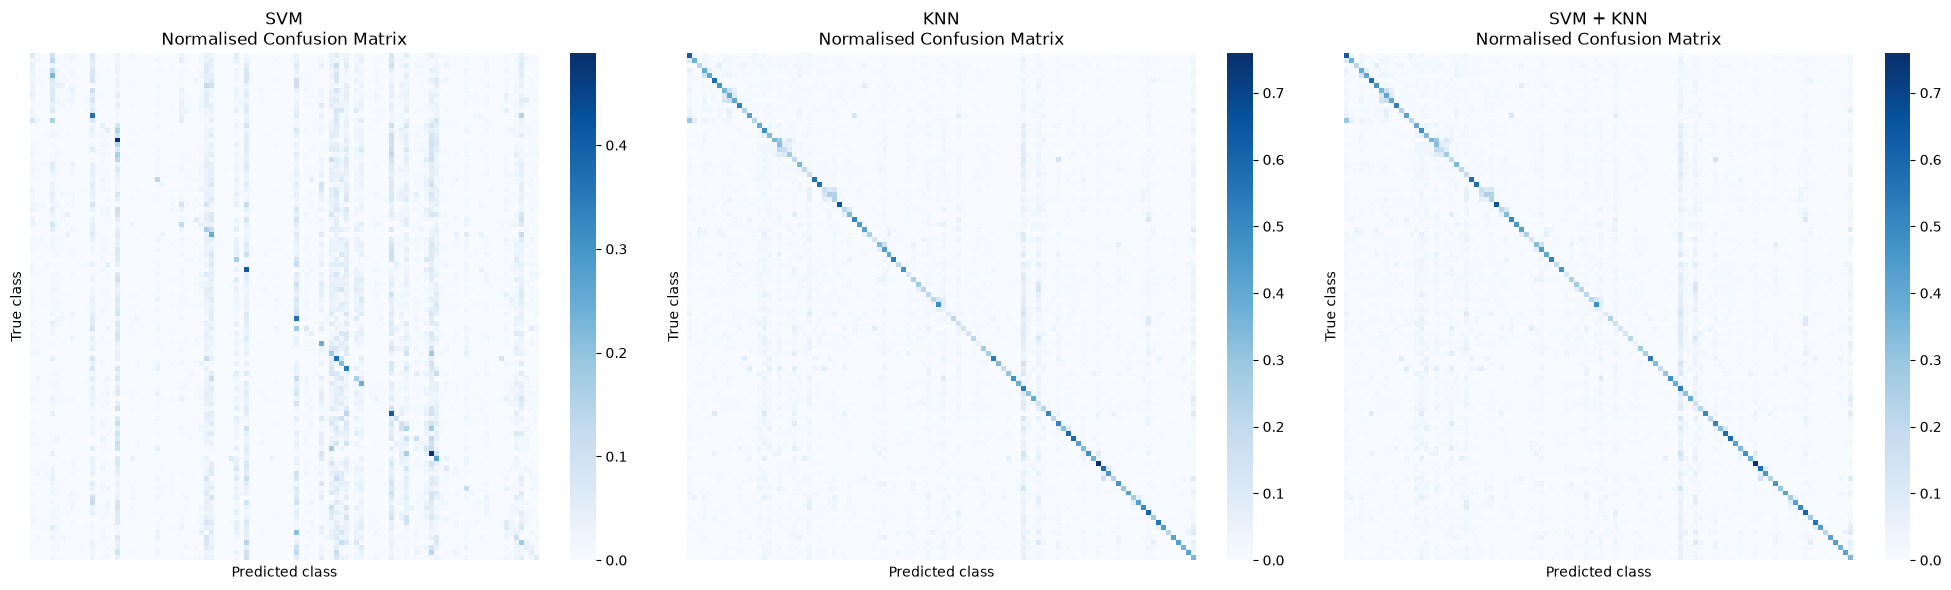

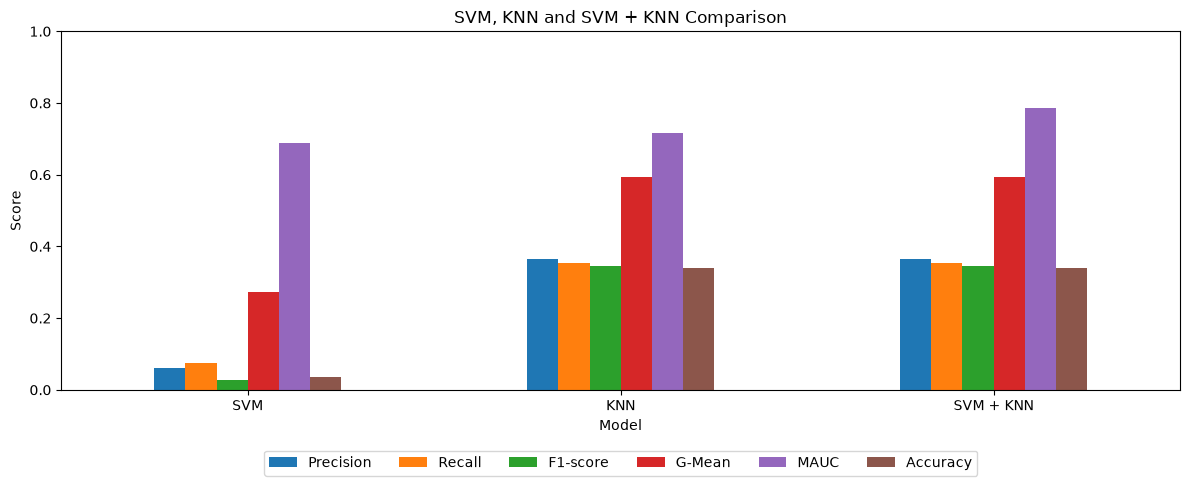

,precision,recall,f1-score,support
rice leaf roller,0.401141,0.629851,0.490128,335.0
rice leaf caterpillar,0.413534,0.374150,0.392857,147.0
paddy stem maggot,0.326923,0.215190,0.259542,79.0
asiatic rice borer,0.391720,0.389241,0.390476,316.0
yellow rice borer,0.449275,0.407895,0.427586,152.0
rice gall midge,0.497175,0.578947,0.534954,152.0
Rice Stemfly,0.388060,0.468468,0.424490,111.0
brown plant hopper,0.358566,0.358566,0.358566,251.0
white backed plant hopper,0.314121,0.406716,0.354472,268.0
small brown plant hopper,0.338384,0.403614,0.368132,166.0


Model saved to: c:\Users\Schhilling\Desktop\COMP9444_Project\svm_knn_outputs\models\svm_knn_ip102.joblib
Results saved to: c:\Users\Schhilling\Desktop\COMP9444_Project\svm_knn_outputs\svm_knn_results.csv
Metrics saved to: c:\Users\Schhilling\Desktop\COMP9444_Project\svm_knn_outputs\svm_knn_metrics.json


In [ ]:
# Create variables for the group comparison table
result_index = svm_knn_results.set_index("Model")

svm_pre = result_index.loc["SVM", "Precision"]
svm_rec = result_index.loc["SVM", "Recall"]
svm_f1 = result_index.loc["SVM", "F1-score"]
svm_gm = result_index.loc["SVM", "G-Mean"]
svm_mauc = result_index.loc["SVM", "MAUC"]
svm_acc = result_index.loc["SVM", "Accuracy"]

knn_pre = result_index.loc["KNN", "Precision"]
knn_rec = result_index.loc["KNN", "Recall"]
knn_f1 = result_index.loc["KNN", "F1-score"]
knn_gm = result_index.loc["KNN", "G-Mean"]
knn_mauc = result_index.loc["KNN", "MAUC"]
knn_acc = result_index.loc["KNN", "Accuracy"]

svm_knn_pre = result_index.loc["SVM + KNN", "Precision"]
svm_knn_rec = result_index.loc["SVM + KNN", "Recall"]
svm_knn_f1 = result_index.loc["SVM + KNN", "F1-score"]
svm_knn_gm = result_index.loc["SVM + KNN", "G-Mean"]
svm_knn_mauc = result_index.loc["SVM + KNN", "MAUC"]
svm_knn_acc = result_index.loc["SVM + KNN", "Accuracy"]

# Plot normalised confusion matrices
fig, axes = plt.subplots(1, len(predictions_by_model), figsize=(20, 6))

for ax, (model_name, predictions) in zip(axes, predictions_by_model.items()):
    sns.heatmap(
        confusion_matrix(y_test, predictions, labels=np.arange(NUM_CLASSES), normalize="true"),
        cmap="Blues",
        xticklabels=False,
        yticklabels=False,
        ax=ax,
    )
    ax.set_title(f"{model_name}\nNormalised Confusion Matrix")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")

plt.tight_layout()
plt.savefig(
    SVM_KNN_FIGURE_DIR / "svm_knn_confusion_matrices.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

# Plot the final comparison chart
plot_columns = ["Precision", "Recall", "F1-score", "G-Mean", "MAUC", "Accuracy"]
axis = svm_knn_results.set_index("Model")[plot_columns].plot.bar(figsize=(12, 5), ylim=(0, 1), rot=0)
axis.set_title("SVM, KNN and SVM + KNN Comparison")
axis.set_xlabel("Model")
axis.set_ylabel("Score")
axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=6)
plt.tight_layout()
plt.savefig(SVM_KNN_FIGURE_DIR / "svm_knn_comparison.png", dpi=180, bbox_inches="tight")
plt.show()
# Save the trained models and preprocessing components
model_file = SVM_KNN_MODEL_DIR / "svm_knn_ip102.joblib"
joblib.dump(
    {
        "scaler": feature_scaler,
        "pca": pca,
        "svm": svm_model,
        "knn": knn_model,
        "svm_weight": svm_weight,
        "knn_weight": knn_weight,
        "class_order": class_order,
        "class_names": class_names,
        "feature_size": FEATURE_SIZE,
        "pca_components": number_of_components,
        "max_train_per_class": MAX_TRAIN_PER_CLASS,
        "seed": SEED
    },
    model_file
)
# Save the comparison results
comparison_csv = SVM_KNN_OUTPUT_DIR / "svm_knn_results.csv"
svm_knn_results.to_csv(comparison_csv, index=False, encoding="utf-8-sig")

# Generate the SVM + KNN per-class report
ensemble_predictions = predictions_by_model["SVM + KNN"]
ensemble_report = classification_report(
    y_test,
    ensemble_predictions,
    labels=np.arange(NUM_CLASSES),
    target_names=class_names,
    output_dict=True,
    zero_division=0)

per_class_report = pd.DataFrame(ensemble_report).transpose()
display(per_class_report.head(20))
per_class_report.to_csv(SVM_KNN_OUTPUT_DIR / "svm_knn_per_class_report.csv", encoding="utf-8-sig")

# Save the metrics in JSON format
metrics_json = SVM_KNN_OUTPUT_DIR / "svm_knn_metrics.json"
metrics_json.write_text(json.dumps(svm_knn_results.to_dict(orient="records"), indent=2), encoding="utf-8")
print("Model saved to:", model_file)
print("Results saved to:", comparison_csv)
print("Metrics saved to:", metrics_json)

<h1 align="center" style="font-size: 2.0rem; margin-bottom: 1.5rem;">Method 2: ResNet-50</h1>
<h2 align="center" style="font-size: 1.1rem; color: #555; margin-bottom: 1.5rem; font-style: italic;">by: Lang Qin</h2>

### **Model Parameters**

In [ ]:
EPOCHS      = 20
PATIENCE    = 5
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
NUM_WORKERS = 0

LEARNING_RATE = 0.0001
WEIGHT_DECAY  = 0.0001

### **Class Label Processing**

In [ ]:
all_labels = pd.concat([train["class"], val["class"], test["class"]],ignore_index=True,)

NUM_CLASSES = int(all_labels.max()) + 1
n_classes = NUM_CLASSES

with open(CLASSES_FILE, "r", encoding="utf-8") as file:
    class_lines = [line.strip() for line in file if line.strip()]

class_names = []

for line in class_lines:
    parts = line.split(maxsplit=1)

    if len(parts) == 2 and parts[0].isdigit():
        class_names.append(parts[1])
    else:
        class_names.append(line)

### **Model Initialization**

In [ ]:
class_count = np.bincount(train["class"].to_numpy(dtype=np.int64), minlength=NUM_CLASSES)
class_weight = len(train_set) / (NUM_CLASSES * class_count)
class_weight = torch.tensor(class_weight, dtype=torch.float32).to(device)

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

loss_function = nn.CrossEntropyLoss(weight=class_weight)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

print("Model: ResNet50")
print("Output classes:", model.fc.out_features)
print("Class weight range:", class_weight.min().item(), class_weight.max().item())

total_params = sum(parameter.numel() for parameter in model.parameters())
trainable_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

print(str(summary(model, input_size=(2, 3, IMAGE_SIZE, IMAGE_SIZE), depth=2, device=device)).split("Total mult-adds")[0])

Model: ResNet50
Output classes: 102
Class weight range: 0.12837044894695282 10.52637767791748
Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [2, 102]                  --
├─Conv2d: 1-1                            [2, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [2, 64, 112, 112]         128
├─ReLU: 1-3                              [2, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [2, 64, 56, 56]           --
├─Sequential: 1-5                        [2, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [2, 256, 56, 56]          75,008
│    └─Bottleneck: 2-2                   [2, 256, 56, 56]          70,400
│    └─Bottleneck: 2-3                   [2, 256, 56, 56]          70,400
├─Sequential: 1-6                        [2, 512, 28, 28]          --
│    └─Bottleneck: 2-4                   [2, 512, 28, 28]          379,392
│    └─Bottleneck: 2-5                  

### **Training & Testing Functions**

In [ ]:
# Mixed precision setup
use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

# GPU monitoring
def get_gpu_info():
    if not torch.cuda.is_available():
        return "CPU", "0 MB"

    try:
        result = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=utilization.gpu,memory.used", "--format=csv,noheader,nounits"],
            text=True,
        ).strip()

        gpu, memory = result.split(",")
        return f"{gpu.strip()}%", f"{memory.strip()} MB"

    except:
        memory = torch.cuda.memory_allocated() / 1024 ** 2
        return "-", f"{memory:.0f} MB"

# Training loop
def train_one_epoch():
    model.train()

    total_loss, correct, total = 0, 0, 0
    gpu_use, gpu_memory = "-", "-"

    bar = tqdm(train_loader, desc="Training")

    for batch, (images, labels) in enumerate(bar):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            outputs = model(images)
            loss = loss_function(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        if batch % 20 == 0:
            gpu_use, gpu_memory = get_gpu_info()

        bar.set_postfix(
            loss=f"{total_loss / total:.4f}",
            acc=f"{correct / total:.4f}",
            gpu=gpu_use,
            memory=gpu_memory,
        )

    return total_loss / total, correct / total

# Evaluation loop
def evaluate(loader):
    model.eval()

    total_loss, correct, total = 0, 0, 0
    all_labels, all_outputs = [], []

    bar = tqdm(loader, desc="Validation")

    with torch.inference_mode():
        for images, labels in bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
                outputs = model(images)
                loss = loss_function(outputs, labels)

            total_loss += loss.item() * labels.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_outputs.extend(outputs.float().cpu().numpy())

            bar.set_postfix(
                loss=f"{total_loss / total:.4f}",
                acc=f"{correct / total:.4f}",
            )

    return (
        total_loss / total,
        correct / total,
        np.array(all_labels),
        np.array(all_outputs),
    )


print("AMP:", use_amp)
print("GPU:", get_gpu_info())

AMP: True
GPU: ('12%', '3122 MB')


### **Model Training**

In [ ]:
# Model training
history = []
best_acc = 0
wait = 0

model_file = "best_resnet50.pth"

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc, _, _ = evaluate(val_loader)

    scheduler.step(val_acc)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
    })

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        wait = 0

        torch.save(model.state_dict(), model_file)

        print("Best model saved.")

    else:
        wait += 1

    if wait >= PATIENCE:
        print("Early stopping.")
        break

training_time = time.time() - start_time

print("\nTraining finished.")
print("Training time:", training_time)
print("Best validation accuracy:", best_acc)
print("Model saved to:", model_file)


Epoch 1/1


Training:   0%|          | 0/1410 [00:00<?, ?it/s]

Validation:   0%|          | 0/235 [00:00<?, ?it/s]

Train Loss: 2.6854 | Train Acc: 0.3864
Val Loss: 1.8008 | Val Acc: 0.5116
Best model saved.

Training finished.
Training time: 436.166202545166
Best validation accuracy: 0.5115876398508258
Model saved to: best_resnet50.pth


In [ ]:
# Load best model

model.load_state_dict(torch.load("best_resnet50.pth", map_location=device, weights_only=True))

model.eval()

print("Best ResNet50 model loaded.")

Best ResNet50 model loaded.


### **Model Testing**

In [ ]:
model.eval()

test_labels = []
test_outputs = []

start_time = time.time()

bar = tqdm(test_loader, desc="Testing")

with torch.inference_mode():
    for images, labels in bar:
        images = images.to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            outputs = model(images)

        test_labels.extend(labels.numpy())
        test_outputs.extend(outputs.float().cpu().numpy())

test_time = time.time() - start_time

test_labels = np.array(test_labels)
test_outputs = np.array(test_outputs)

test_predictions = test_outputs.argmax(axis=1)

print("Test images:", len(test_labels))
print("Test time:", test_time)
print("Inference time per image:", test_time / len(test_labels))

Testing:   0%|          | 0/707 [00:00<?, ?it/s]

Test images: 22619
Test time: 114.66085720062256
Inference time per image: 0.005069227516717033


### **Model Evaluation**

In [ ]:
test_probabilities = torch.softmax(torch.tensor(test_outputs), dim=1).numpy()

accuracy = accuracy_score(test_labels, test_predictions)

precision = precision_score(
    test_labels, test_predictions, average="macro", zero_division=0
)

recall = recall_score(
    test_labels, test_predictions, average="macro", zero_division=0
)

f1 = f1_score(
    test_labels, test_predictions, average="macro", zero_division=0
)

gmean = geometric_mean_score(
    test_labels, test_predictions, average="macro"
)

test_one_hot = label_binarize(test_labels, classes=np.arange(NUM_CLASSES))

mauc = roc_auc_score(
    test_one_hot, test_probabilities, average="macro", multi_class="ovr"
)

top5_predictions = np.argsort(test_probabilities, axis=1)[:, -5:]

top5_accuracy = np.mean([
    label in predictions
    for label, predictions in zip(test_labels, top5_predictions)
])

print("ResNet-50")
print("---------")
print(f"Pre  : {precision:.4f}")
print(f"Rec  : {recall:.4f}")
print(f"F1   : {f1:.4f}")
print(f"GM   : {gmean:.4f}")
print(f"MAUC : {mauc:.4f}")
print(f"Acc  : {accuracy:.4f}")
print(f"Top-5: {top5_accuracy:.4f}")

ResNet-50
---------
Pre  : 0.4331
Rec  : 0.5046
F1   : 0.4342
GM   : 0.7086
MAUC : 0.9702
Acc  : 0.5121
Top-5: 0.8096


In [ ]:
# Save Model Metrics
metrics = {
    "model": "ResNet50",
    "pretrained": True,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "geometric_mean_score": gmean,
    "mauc": mauc,
    "accuracy": accuracy,
    "top5_accuracy": top5_accuracy,
    "training_time_seconds": training_time,
    "test_time_seconds": test_time,
    "inference_time_ms": test_time / len(test_labels) * 1000,
    "best_validation_accuracy": best_acc,
    "total_parameters": total_params,
    "trainable_parameters": trainable_params,
}

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv("resnet50_metrics.csv", index=False)

with open("resnet50_metrics.json", "w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)

display(metrics_df)

,model,pretrained,precision,recall,f1,geometric_mean_score,mauc,accuracy,top5_accuracy,training_time_seconds,test_time_seconds,inference_time_ms,best_validation_accuracy,total_parameters,trainable_parameters
0,ResNet50,True,0.433149,0.50456,0.434212,0.708605,0.97019,0.512136,0.809585,436.166203,114.660857,5.069228,0.511588,23717030,23717030


 #### **Training Analysis**

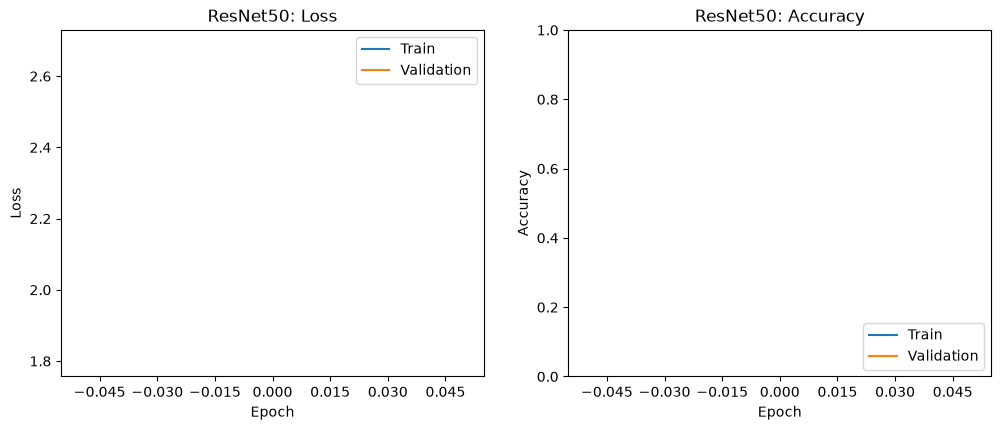

Training history and figures saved.


In [ ]:
history_df = pd.DataFrame(history)

history_df.to_csv("resnet50_training_history.csv", index=False)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

# Loss plot
axs[0].xaxis.set_major_locator(MaxNLocator(integer=True))

axs[0].plot(history_df["train_loss"], label="Train")
axs[0].plot(history_df["val_loss"], label="Validation")

axs[0].set_title("ResNet50: Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()

# Accuracy plot
axs[1].xaxis.set_major_locator(MaxNLocator(integer=True))

train_acc_decimal = np.array(history_df["train_accuracy"]) / 100.0
val_acc_decimal = np.array(history_df["val_accuracy"]) / 100.0

axs[1].plot(train_acc_decimal, label="Train")
axs[1].plot(val_acc_decimal, label="Validation")

axs[1].set_title("ResNet50: Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].set_ylim(0.0, 1.0)
axs[1].legend(loc="lower right")

fig.savefig("resnet50_training_analysis.png", dpi=300, bbox_inches="tight")

plt.show()

print("Training history and figures saved.")

 #### **Confusion Matrix Analysis**

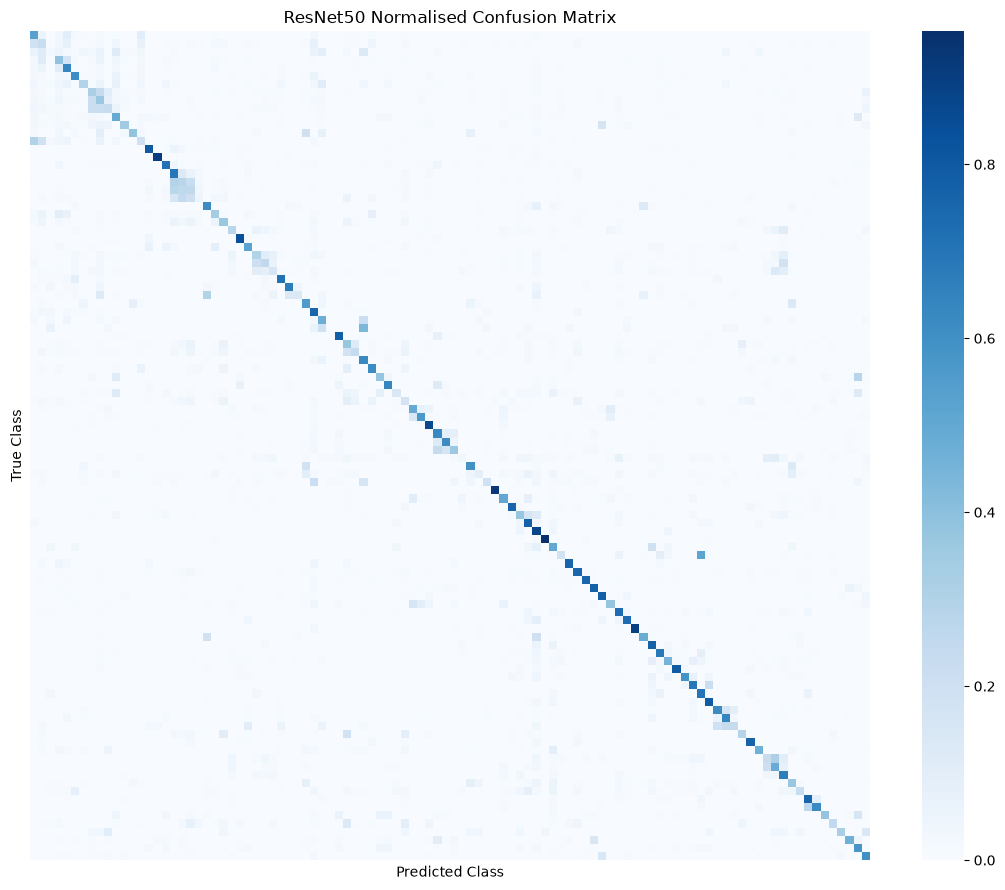

Confusion matrix saved.


In [ ]:
matrix = confusion_matrix(
    test_labels,
    test_predictions,
    labels=np.arange(NUM_CLASSES),
    normalize="true",
)

plt.figure(figsize=(11, 9))

sns.heatmap(
    matrix,
    cmap="Blues",
    xticklabels=False,
    yticklabels=False,
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("ResNet50 Normalised Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "resnet50_confusion_matrix.png",
    dpi=180,
)

plt.show()

print("Confusion matrix saved.")

 #### **Common Confusion Analysis**

In [ ]:
error_count = {}

for true_label, predicted_label in zip(test_labels, test_predictions):
    if true_label == predicted_label:
        continue

    pair = (int(true_label), int(predicted_label))
    error_count[pair] = error_count.get(pair, 0) + 1

top_errors = sorted(
    error_count.items(),
    key=lambda item: item[1],
    reverse=True,
)[:15]

error_data = []

for (true_label, predicted_label), count in top_errors:
    error_data.append({
        "True Class": class_names[true_label],
        "Predicted Class": class_names[predicted_label],
        "Count": count,
    })

error_df = pd.DataFrame(error_data)

display(error_df)

error_df.to_csv("resnet50_common_confusions.csv", index=False)

,True Class,Predicted Class,Count
0,Cicadellidae,Cicadella viridis,241
1,Miridae,alfalfa plant bug,240
2,Miridae,tarnished plant bug,142
3,aphids,Aphis citricola Vander Goot,135
4,blister beetle,lytta polita,135
5,blister beetle,legume blister beetle,94
6,Miridae,Apolygus lucorum,91
7,beet army worm,cabbage army worm,87
8,black cutworm,white margined moth,75
9,aphids,english grain aphid,74


 #### **Common Confusion Visualization**

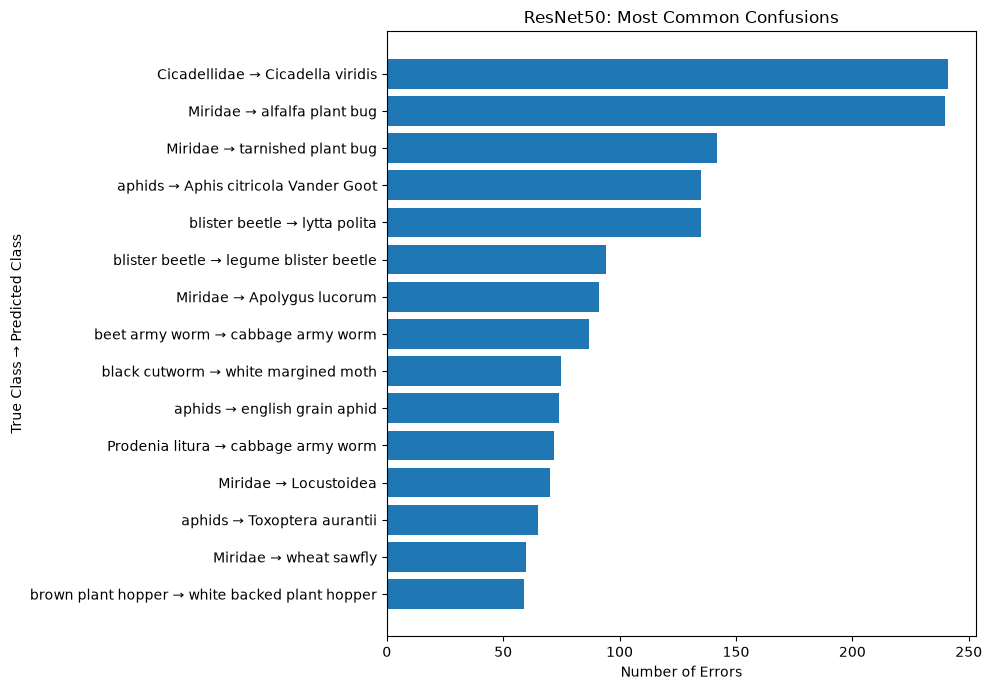

Confusion plot saved.


In [ ]:
labels = [
    f"{row['True Class']} → {row['Predicted Class']}"
    for _, row in error_df.iterrows()
]

plt.figure(figsize=(10, 7))

plt.barh(labels[::-1], error_df["Count"][::-1],)

plt.xlabel("Number of Errors")
plt.ylabel("True Class → Predicted Class")
plt.title("ResNet50: Most Common Confusions")
plt.tight_layout()

plt.savefig("resnet50_common_confusions.png", dpi=180, bbox_inches="tight")

plt.show()

print("Confusion plot saved.")

 #### **Classification Report**

In [ ]:
report = classification_report(
    test_labels,
    test_predictions,
    labels=np.arange(NUM_CLASSES),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).transpose()

display(report_df.head(20))

report_df.to_csv("resnet50_classification_report.csv")

print("Classification report saved.")

,precision,recall,f1-score,support
rice leaf roller,0.523529,0.531343,0.527407,335.0
rice leaf caterpillar,0.126437,0.224490,0.161765,147.0
paddy stem maggot,0.033333,0.025316,0.028777,79.0
asiatic rice borer,0.359649,0.389241,0.373860,316.0
yellow rice borer,0.295732,0.638158,0.404167,152.0
rice gall midge,0.436620,0.611842,0.509589,152.0
Rice Stemfly,0.383721,0.297297,0.335025,111.0
brown plant hopper,0.323887,0.318725,0.321285,251.0
white backed plant hopper,0.272222,0.365672,0.312102,268.0
small brown plant hopper,0.233129,0.228916,0.231003,166.0


Classification report saved.


 #### **Class Performance Analysis**

In [ ]:
class_report = report_df.iloc[:NUM_CLASSES].copy()

best_classes = class_report.sort_values(
    "f1-score",
    ascending=False,
).head(10)

worst_classes = class_report.sort_values(
    "f1-score",
    ascending=True,
).head(10)

print("Best 10 classes:")
display(best_classes)

print("Worst 10 classes:")
display(worst_classes)

best_classes.to_csv("resnet50_best_classes.csv")

worst_classes.to_csv("resnet50_worst_classes.csv")

Best 10 classes:


,precision,recall,f1-score,support
mole cricket,0.946921,0.901010,0.923395,495.0
Pieris canidia,0.915493,0.921986,0.918728,141.0
Papilio xuthus,0.930769,0.896296,0.913208,135.0
oides decempunctata,0.843750,0.952941,0.895028,85.0
Lycorma delicatula,0.957041,0.754705,0.843914,1594.0
Limacodidae,0.837270,0.757720,0.795511,421.0
Potosiabre vitarsis,0.739583,0.835294,0.784530,170.0
Aleurocanthus spiniferus,0.746606,0.793269,0.769231,208.0
grub,0.733096,0.798450,0.764378,258.0
Locustoidea,0.675978,0.866348,0.759414,419.0


Worst 10 classes:


,precision,recall,f1-score,support
beet fly,0.000000,0.000000,0.000000,32.0
paddy stem maggot,0.033333,0.025316,0.028777,79.0
therioaphis maculata Buckton,0.061224,0.038462,0.047244,78.0
yellow cutworm,0.120690,0.048611,0.069307,144.0
Polyphagotars onemus latus,0.067708,0.500000,0.119266,26.0
Thrips,0.289157,0.090909,0.138329,264.0
Brevipoalpus lewisi McGregor,0.082353,0.875000,0.150538,24.0
rice leaf caterpillar,0.126437,0.224490,0.161765,147.0
Toxoptera citricidus,0.127451,0.228070,0.163522,57.0
rice shell pest,0.169014,0.195122,0.181132,123.0


 #### **Class Performance Visualization**

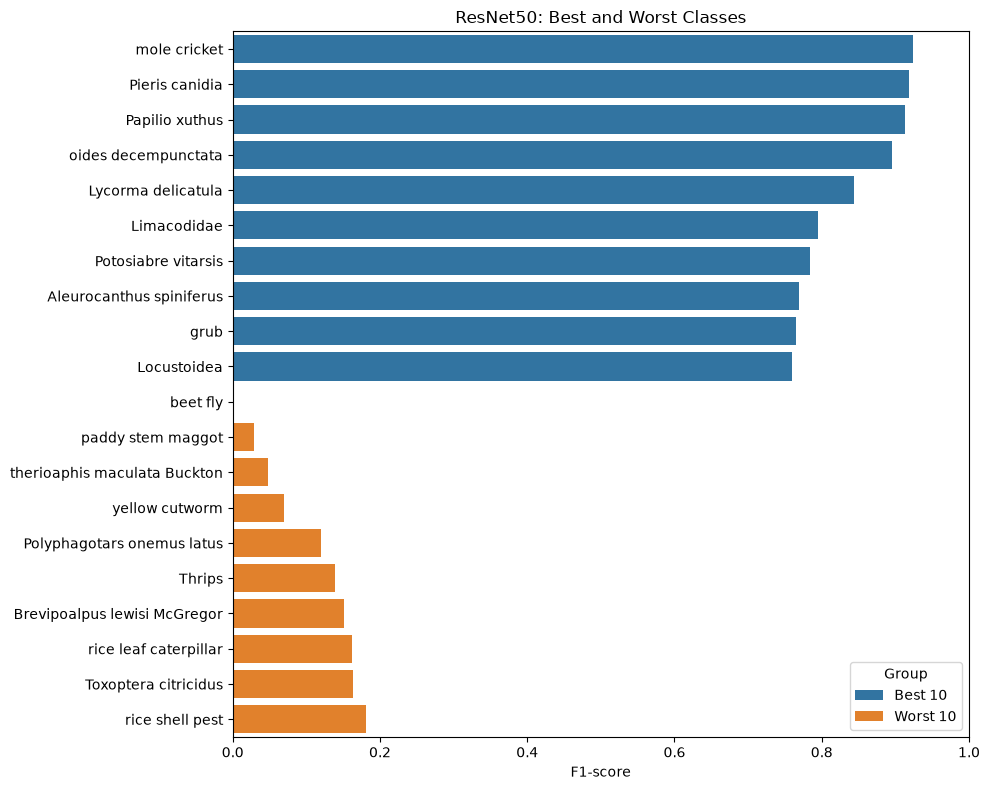

Best and worst class plot saved.


In [ ]:
plot_data = pd.concat([
    best_classes.assign(Group="Best 10"),
    worst_classes.assign(Group="Worst 10"),
])

plot_data = plot_data.reset_index().rename(columns={"index": "Class"})

plt.figure(figsize=(10, 8))

sns.barplot(
    data=plot_data,
    x="f1-score",
    y="Class",
    hue="Group",
)

plt.xlabel("F1-score")
plt.ylabel("")
plt.title("ResNet50: Best and Worst Classes")
plt.xlim(0, 1)
plt.tight_layout()

plt.savefig("resnet50_best_worst_classes.png", dpi=180, bbox_inches="tight")

plt.show()

print("Best and worst class plot saved.")

<h1 align="center" style="font-size: 2.0rem; margin-bottom: 0.5rem;">Method 3: InsecNet (Custom CNN)</h1>
<h2 align="center" style="font-size: 1.1rem; color: #555; margin-bottom: 1.5rem; font-style: italic;">by: BinBin Dong</h2>

InsecNet is a modified DenseNet-121-based model with four dense blocks (6, 12, 24, 16). Each dense layer uses 1×1 and 3×3 convolutions for efficient feature extraction, with ECA modules added to improve channel attention. The model also uses SiLU activation, dropout, gradient checkpointing, and a custom classifier for 102 insect classes.

#### **Architecture Overview**

| Stage | Module Name | Core Operators & Features | Output Resolution |
| :--- | :--- | :--- | :--- |
| **Input** | `Data Stream` | RGB Input Image | $3 \times 224 \times 224$ |
| **Stem** | `conv0` + `pool0` | Conv (7x7) ➔ BatchNorm ➔ SiLU ➔ MaxPool | $64 \times 56 \times 56$ |
| **Stage 1** | `denseblock1` | 6 $\times$ [Dense Layer + ECA] + Dropout | $256 \times 56 \times 56$ |
| | `transition1` | BatchNorm ➔ SiLU ➔ Conv (1x1) ➔ AvgPool | $128 \times 28 \times 28$ |
| **Stage 2** | `denseblock2` | 12 $\times$ [Dense Layer + ECA] + Dropout | $512 \times 28 \times 28$ |
| | `transition2` | BatchNorm ➔ SiLU ➔ Conv (1x1) ➔ AvgPool | $256 \times 14 \times 14$ |
| **Stage 3** | `denseblock3` | 24 $\times$ [Dense Layer + ECA] + Dropout | $1024 \times 14 \times 14$ |
| | `transition3` | BatchNorm ➔ SiLU ➔ Conv (1x1) ➔ AvgPool | $512 \times 7 \times 7$ |
| **Stage 4** | `denseblock4` | 16 $\times$ [Dense Layer + ECA] + Dropout | $1024 \times 7 \times 7$ |
| **Norm** | `norm5` | Final BatchNorm2d + SiLU Activation | $1024 \times 7 \times 7$ |
| **Head** | `classifier` | AdaptiveAvgPool ➔ Flatten ➔ Deep Linear Head | 102 Classes |

In [ ]:
class eca_block(nn.Module):                     # Efficient Channel Attention
    def __init__(self, channels, k_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1) # Get a single value per channel
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = y.squeeze(-1).transpose(1, 2)       # Adjust shape for 1D convolution
        y = self.conv(y)                        # Learn which channels are important
        y = y.transpose(1, 2).unsqueeze(-1)     # Restore original image shape
        return x * self.sigmoid(y)              # Multiply input by attention scores

class dense_layer(nn.Module):                   # Single layer inside a block
    def __init__(self, in_channels, growth_rate):
        super().__init__()

        self.norm1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, 4 * growth_rate, kernel_size=1, bias=False) # Bottleneck to save memory

        self.norm2 = nn.BatchNorm2d(4 * growth_rate)
        self.conv2 = nn.Conv2d(4 * growth_rate, growth_rate, kernel_size=3, padding=1, bias=False) # Main feature extractor

        self.eca = eca_block(growth_rate)       # Apply channel attention

    def forward(self, *prev_features):
        x = torch.cat(prev_features, dim=1)     # Combine outputs from all previous layers
        out = self.conv1(F.relu(self.norm1(x)))
        out = self.conv2(F.relu(self.norm2(out)))
        return self.eca(out)                    # Return new features with attention applied

class dense_block(nn.Module):                   # Group of densely connected layers
    def __init__(self, num_layers, in_channels, growth_rate, use_checkpoint=False):
        super().__init__()
        self.use_checkpoint = use_checkpoint

        for i in range(num_layers):
            layer = dense_layer(in_channels + i * growth_rate, growth_rate)
            self.add_module(f"denselayer{i + 1}", layer) # Naming matches ImageNet weights perfectly

    def forward(self, x):
        features = [x]
        for name, layer in self.named_children():
            if self.use_checkpoint and self.training:
                new_features = cp.checkpoint(layer, *features, use_reentrant=False) # Saves GPU memory
            else:
                new_features = layer(*features)

            new_features = F.dropout(new_features, p=0.1, training=self.training)   # Prevent overfitting
            features.append(new_features)

        return torch.cat(features, dim=1)       # Output all collected features

class transition_layer(nn.Module):     # Reduces image size and channel count
    def __init__(self, in_channels, compression=0.5):
        super().__init__()
        self.out_channels = int(in_channels * compression) # Cut channels in half

        self.norm = nn.BatchNorm2d(in_channels)
        self.relu = nn.SiLU()
        self.conv = nn.Conv2d(in_channels, self.out_channels, kernel_size=1, bias=False)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        return self.pool(self.conv(self.relu(self.norm(x))))

class InsecNet(nn.Module):             # Main custom model
    def __init__(self, n_classes=102, growth_rate=32, blocks=(6, 12, 24, 16)):
        super().__init__()
        channels = 2 * growth_rate

        self.features = nn.Sequential() # ImageNet-compatible backbone

        # Initial setup (Stem)
        self.features.add_module("conv0", nn.Conv2d(3, channels, kernel_size=7, stride=2, padding=3, bias=False))
        self.features.add_module("norm0", nn.BatchNorm2d(channels))
        self.features.add_module("relu0", nn.SiLU())
        self.features.add_module("pool0", nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

        # Add Dense Blocks and Transition Layers
        for i, num_layers in enumerate(blocks):
            block = dense_block(num_layers, channels, growth_rate, use_checkpoint=True)
            self.features.add_module(f"denseblock{i+1}", block)
            channels += num_layers * growth_rate

            # Add a transition layer after every block except the last one
            if i != len(blocks) - 1:
                trans = transition_layer(channels)
                self.features.add_module(f"transition{i+1}", trans)
                channels = trans.out_channels

        # Final backbone layers
        self.features.add_module("norm5", nn.BatchNorm2d(channels))
        self.features.add_module("relu5", nn.SiLU())

        # Prediction head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(channels, 512),
            nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(512, n_classes)
        )

        self._initialize_weights()

    def _initialize_weights(self):     # Set smart starting weights for faster training
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None: nn.init.constant_(m.bias, 0)

    def forward(self, x):
        features = self.features(x)
        return self.classifier(features)

# Print model stats
print(str(summary(InsecNet(n_classes=n_classes), input_size=(2, 3, 224, 224), depth=2)).split("Total mult-adds")[0])

Layer (type:depth-idx)                             Output Shape              Param #
InsecNet                                           [2, 102]                  --
├─Sequential: 1-1                                  [2, 1024, 7, 7]           --
│    └─Conv2d: 2-1                                 [2, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                            [2, 64, 112, 112]         128
│    └─SiLU: 2-3                                   [2, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                              [2, 64, 56, 56]           --
│    └─dense_block: 2-5                            [2, 256, 56, 56]          335,058
│    └─transition_layer: 2-6                       [2, 128, 28, 28]          33,280
│    └─dense_block: 2-7                            [2, 512, 28, 28]          919,716
│    └─transition_layer: 2-8                       [2, 256, 14, 14]          132,096
│    └─dense_block: 2-9                            [2, 1024, 14, 14]         2,837,832
│    

 #### **Training Function**
The training function features automated early stopping, gradient clipping, and dynamic checkpointing to ensure stable and optimal model convergence.

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device,
              epochs=50, patience=7, min_delta=1e-3, save_path='best_model.pth'):
    logs = {'tr_loss': [], 'tr_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0
    counter  = 0

    for epoch in range(epochs):
        # Training phase
        model.train()
        tr_loss, tr_hits, tr_total = 0.0, 0, 0

        for inputs, labels in tqdm(
                train_loader,
                desc=f"Epoch {epoch+1}/{epochs} Training"):

            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            tr_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)
            tr_total += labels.size(0)
            tr_hits  += (predicted == labels).sum().item()

        avg_tr_loss = tr_loss / tr_total
        tr_acc = 100 * tr_hits / tr_total

        # Training phase
        model.eval()
        val_loss, val_hits, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in tqdm(
                    val_loader,
                    desc="Validation"):

                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_hits += (predicted == labels).sum().item()

        avg_val_loss = val_loss / val_total
        val_acc      = 100 * val_hits / val_total

        # Save logs
        logs['tr_loss'].append(avg_tr_loss)
        logs['tr_acc'].append(tr_acc)
        logs['val_loss'].append(avg_val_loss)
        logs['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_tr_loss:.3f} | Val Loss: {avg_val_loss:.3f} | Val Acc: {val_acc:.2f}%")

        # Early stopping & Checkpointing
        if val_acc > best_acc + min_delta:
            best_acc = val_acc
            counter = 0
            torch.save(model.state_dict(), save_path)
            print(f"Saved best model ({best_acc:.2f}%)")
        else:
            counter += 1
            print(f"No improvement ({counter}/{patience})")

        scheduler.step()

        if counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}.")
            break


    model.load_state_dict(
        torch.load(
            save_path,
            map_location=device,
            weights_only=True,
        )
    )  # Load the best weights

    return logs

 #### **Model Configuration**
Configures the network hyperparameters, utilizing a class-balanced loss function to handle dataset imbalance and label smoothing to prevent overfitting.

In [ ]:
# Hyperparameters
GROWTH_RATE = 32
BLOCKS = (6, 12, 24, 16)

LEARNING_RATE = 0.0001
WEIGHT_DECAY  = 0.0001

EPOCHS    = 20
PATIENCE  = 5
MIN_DELTA = 0.001

BETA = 0.999
LABEL_SMOOTHING = 0.05

T_MAX = EPOCHS

# Dataset information
class_counts = train['class'].value_counts().sort_index()
n_classes = len(class_counts)

# Class balanced loss
effective_num = 1.0 - BETA ** class_counts.values
weights = (1.0 - BETA) / effective_num
weights = weights / weights.mean()
weights = torch.tensor(weights, dtype=torch.float32, device=device)
criterion = torch.nn.CrossEntropyLoss(weight=weights, label_smoothing=LABEL_SMOOTHING)

 #### **Model Training**
Initializes the model from scratch, sets up the optimization pipeline with AdamW and a Cosine Annealing scheduler, and executes the complete training and validation loop while tracking total runtime.

In [ ]:
SAVE_PATH = "insecnet_scratch.pth"

# Setup InsecNet from scratch
model     = InsecNet(n_classes=n_classes, growth_rate=GROWTH_RATE, blocks=BLOCKS).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_MAX)

start_train_time = time.time()

# Train InsecNet Scratch
logs_insecnet = train_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion,
    optimizer    = optimizer,
    scheduler    = scheduler,
    device       = device,
    epochs       = EPOCHS,
    patience     = PATIENCE,
    min_delta    = MIN_DELTA,
    save_path    = SAVE_PATH
)

end_train_time = time.time()

Epoch 1/1 Training:   0%|          | 0/1410 [00:00<?, ?it/s]

Validation:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 1/1 | Train Loss: 4.758 | Val Loss: 4.603 | Val Acc: 11.29%
Saved best model (11.29%)


 #### **Transfer Learning (ImageNet)**
Uses pre-trained ImageNet weights to leverage transfer learning, configures the AdamW optimizer, and executes the complete training and validation pipeline.

In [ ]:
SAVE_PATH = "insecnet_imagenet.pth"

model = InsecNet(n_classes=n_classes, growth_rate=GROWTH_RATE, blocks=BLOCKS).to(device)
pretrained_dict = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1).state_dict() # Load pretrained weights
model.load_state_dict(pretrained_dict, strict=False)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

start_train_time = time.time()

logs_insecnet_w = train_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion,
    optimizer    = optimizer,
    scheduler    = scheduler,
    device       = device,
    epochs       = EPOCHS,
    patience     = PATIENCE,
    min_delta    = MIN_DELTA,
    save_path    = SAVE_PATH
)

end_train_time = time.time()

Epoch 1/1 Training:   0%|          | 0/1410 [00:00<?, ?it/s]

Validation:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 1/1 | Train Loss: 4.218 | Val Loss: 3.206 | Val Acc: 43.55%
Saved best model (43.55%)


 #### **Training Analysis**
Plots loss and accuracy curves across epochs to compare training performance between training from scratch and using pre-trained ImageNet weights.

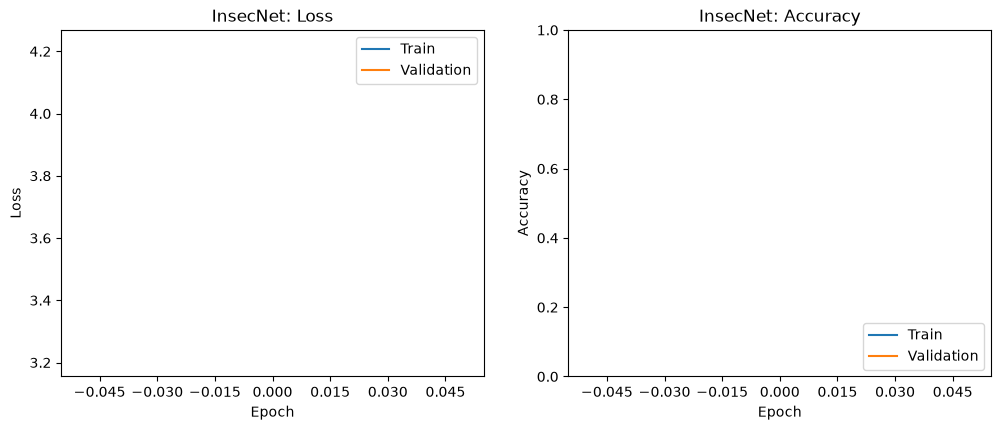

In [ ]:
# Learning curves visualization
# Create a 2x2 grid for comparison
fig, axs = plt.subplots(2, 2, figsize=(14, 9))

# Plot 1: InsecNet Loss
axs[0, 0].xaxis.set_major_locator(MaxNLocator(integer=True))
axs[0, 0].plot(logs_insecnet['tr_loss'], label='Train', color='tab:blue')
axs[0, 0].plot(logs_insecnet['val_loss'], label='Validation', color='tab:orange')
axs[0, 0].set_title('InsecNet (Scratch): Loss')
axs[0, 0].set_xlabel('Epoch')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: InsecNet Accuracy
axs[0, 1].xaxis.set_major_locator(MaxNLocator(integer=True))
train_acc_scratch = np.array(logs_insecnet['tr_acc']) / 100.0
val_acc_scratch   = np.array(logs_insecnet['val_acc']) / 100.0

axs[0, 1].plot(train_acc_scratch, label='Train', color='tab:blue')
axs[0, 1].plot(val_acc_scratch, label='Validation', color='tab:orange')
axs[0, 1].set_title('InsecNet (Scratch): Accuracy')
axs[0, 1].set_xlabel('Epoch')
axs[0, 1].set_ylabel('Accuracy')
axs[0, 1].set_ylim(0.0, 1.0)
axs[0, 1].legend(loc='lower right')
axs[0, 1].grid(True, linestyle='--', alpha=0.5)

# Plot 3: InsecNet(ImageNet) Loss
axs[1, 0].xaxis.set_major_locator(MaxNLocator(integer=True))
axs[1, 0].plot(logs_insecnet_w['tr_loss'], label='Train', color='tab:green')
axs[1, 0].plot(logs_insecnet_w['val_loss'], label='Validation', color='tab:red')
axs[1, 0].set_title('InsecNet (Pre-trained): Loss')
axs[1, 0].set_xlabel('Epoch')
axs[1, 0].set_ylabel('Loss')
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle='--', alpha=0.5)

# Plot 4: InsecNet(ImageNet) Accuracy 
axs[1, 1].xaxis.set_major_locator(MaxNLocator(integer=True))
train_acc_pretrained = np.array(logs_insecnet_w['tr_acc']) / 100.0
val_acc_pretrained   = np.array(logs_insecnet_w['val_acc']) / 100.0

axs[1, 1].plot(train_acc_pretrained, label='Train', color='tab:green')
axs[1, 1].plot(val_acc_pretrained, label='Validation', color='tab:red')
axs[1, 1].set_title('InsecNet (Pre-trained): Accuracy')
axs[1, 1].set_xlabel('Epoch')
axs[1, 1].set_ylabel('Accuracy')
axs[1, 1].set_ylim(0.0, 1.0)
axs[1, 1].legend(loc='lower right')
axs[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Save the plot 
fig.savefig("insecnet_training_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

 #### **Model Evaluation**
Evaluates the model on the test dataset, measures inference time per image, and computes comprehensive performance metrics.

In [ ]:
def test_model(model, test_loader, device):
    model.eval()
    y_test_true, y_test_pred, y_test_prob = [], [], []

    if device.type == 'cuda': torch.cuda.synchronize()
    start_time = time.time()

    with torch.no_grad():
        test_bar = tqdm(test_loader, desc="Testing", unit="batch")

        for inputs, labels in test_bar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, dim=1)

            y_test_pred.extend(preds.cpu().numpy())
            y_test_true.extend(labels.cpu().numpy())
            y_test_prob.extend(probs.cpu().numpy())

    if device.type == 'cuda': torch.cuda.synchronize()
    test_time = time.time() - start_time

    total_images = len(y_test_true)

    print(f"Test time: {test_time:.4f} seconds")
    print(f"Infer time / image: {test_time / total_images:.6f} seconds")

    y_test_true = np.array(y_test_true)
    y_test_pred = np.array(y_test_pred)
    y_test_prob = np.array(y_test_prob)

    # Metrics
    precision = precision_score(y_test_true, y_test_pred, average="macro", zero_division=0)
    recall    = recall_score( y_test_true, y_test_pred, average="macro", zero_division=0)
    f1        = f1_score(y_test_true, y_test_pred, average="macro", zero_division=0)
    gm        = geometric_mean_score(y_test_true, y_test_pred, average="macro")
    mauc      = roc_auc_score(y_test_true, y_test_prob, multi_class="ovr", average="macro")
    acc       = accuracy_score(y_test_true, y_test_pred)

    print(f"Pre  : {precision:.4f}")
    print(f"Rec  : {recall:.4f}")
    print(f"F1   : {f1:.4f}")
    print(f"GM   : {gm:.4f}")
    print(f"MAUC : {mauc:.4f}")
    print(f"Acc  : {acc:.4f}")

    return y_test_true, y_test_pred, y_test_prob, precision, recall, f1, gm, mauc, acc, test_time

In [ ]:
# Evaluate base InsecNet
print("\nInsecNet (Scratch)")
print("------------------")
model = InsecNet(n_classes=n_classes).to(device)
model.load_state_dict(torch.load('insecnet_scratch.pth', map_location=device, weights_only=True))
insec_true, insec_pred, insec_prob, insec_pre, insec_rec, insec_f1, insec_gm, insec_mauc, insec_acc, insec_time = test_model(model, test_loader, device)

Testing:   0%|          | 0/707 [00:00<?, ?batch/s]

Test time: 178.1861 seconds
Infer time / image: 0.007878 seconds
Evaluation Metrics
------------------
Pre  : 0.0515
Rec  : 0.0564
F1   : 0.0302
GM   : 0.2364
MAUC : 0.7265
Acc  : 0.1109


In [ ]:
# Evaluate InsecNet with Imagenet weights
print("\nInsecNet (ImageNet)")
print("-------------------")
model = InsecNet(n_classes=n_classes).to(device)
model.load_state_dict(torch.load('insecnet_imagenet.pth', map_location=device, weights_only=True))
insec_true_w, insec_pred_w, insec_prob_w, insec_pre_w, insec_rec_w, insec_f1_w, insec_gm_w, insec_mauc_w, insec_acc_w, insec_time_w = test_model(model, test_loader, device)

Testing:   0%|          | 0/707 [00:00<?, ?batch/s]

Test time: 135.0134 seconds
Infer time / image: 0.005969 seconds
Evaluation Metrics
------------------
Pre  : 0.3093
Rec  : 0.3390
F1   : 0.2921
GM   : 0.5806
MAUC : 0.9386
Acc  : 0.4358


 ### **Hybrid Models: Deep Feature Extraction + Machine Learning**
 #### **Feature Extraction**
Loads the trained model weights and utilizes a PyTorch forward hook to extract deep features from an intermediate classifier layer. The extracted features are then normalized using standard scaling and saved along with their corresponding labels for machine learning classification.

In [ ]:
# Load weights
model = InsecNet(n_classes=n_classes)
model.load_state_dict(torch.load('insecnet_imagenet.pth', map_location=device, weights_only=True))
model.eval().to(device)

# Build dedicated unaugmented training loader
fe_train_set    = IP102(dataframe=train, img_dir=IMAGE_DIR, transform=eval_tf)
fe_train_loader = DataLoader(fe_train_set, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

# Feature extraction
def extract_features(model, dataloader, device):
    features_list, labels_list = [], []

    # Intercept layer output
    def hook_fn(module, input, output):
        features_list.append(output.detach().cpu().numpy()) # Save features to RAM

    # Register hook to the specific classifier layer index [3]
    hook_handle = model.classifier[3].register_forward_hook(hook_fn)

    # Disable gradient calculations
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Extracting Features"):
            inputs = inputs.to(device)

            _ = model(inputs)  # Forward pass triggers hook
            labels_list.append(labels.numpy())  # Save truth labels

    hook_handle.remove() # Remove hook from memory

    # Combine all batch arrays
    X = np.concatenate(features_list, axis=0)
    y = np.concatenate(labels_list, axis=0)
    return X, y

X_train, y_train = extract_features(model, fe_train_loader, device) # Extract training features
X_test, y_test   = extract_features(model, test_loader, device)     # Extract testing features

print(f"Extraction Completed. Shapes: Train {X_train.shape}, Test {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Transform training data
X_test_scaled  = scaler.transform(X_test)      # Transform testing data

# Save features
np.savez('extracted_features.npz',
         X_train=X_train_scaled, y_train=y_train,
         X_test=X_test_scaled, y_test=y_test)

Extracting Features:   0%|          | 0/1410 [00:00<?, ?it/s]

Extracting Features:   0%|          | 0/707 [00:00<?, ?it/s]

Extraction Completed. Shapes: Train (45095, 512), Test (22619, 512)


#### **SVM Classifier**
Loads the extracted deep features, applies $L_2$ normalization, and trains a linear SVM via stochastic gradient descent with a class-balanced hinge loss. Then generates predictions to evaluate classification performance across chosen metrics.

In [ ]:
data = np.load('extracted_features.npz')
X_train, y_train = data['X_train'], data['y_train']
X_test, y_test   = data['X_test'], data['y_test']

scaler = Normalizer(norm='l2')
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

svm_classifier = SGDClassifier(
    loss='modified_huber',
    penalty='l2',
    alpha=0.0001,
    class_weight='balanced',
    average=True,
    max_iter=5000,
    tol=1e-5,
    random_state=SEED,
    n_jobs=-1
)
svm_classifier.fit(X_train_scaled, y_train)

svm_preds  = svm_classifier.predict(X_test_scaled)
svm_scores = svm_classifier.decision_function(X_test_scaled)
svm_probs  = softmax(svm_scores, axis=1)

insec_svm_pre = precision_score(y_test, svm_preds, average="macro", zero_division=0)
insec_svm_rec = recall_score(y_test, svm_preds, average="macro", zero_division=0)
insec_svm_f1  = f1_score(y_test, svm_preds, average="macro", zero_division=0)
insec_svm_gm  = geometric_mean_score(y_test, svm_preds, average="macro")
insec_svm_mauc = roc_auc_score(y_test, svm_probs, multi_class="ovr", average="macro")
insec_svm_acc = accuracy_score(y_test, svm_preds)

print("InsecNet + SVM")
print("--------------")
print(f"Pre  : {insec_svm_pre:.4f}")
print(f"Rec  : {insec_svm_rec:.4f}")
print(f"F1   : {insec_svm_f1:.4f}")
print(f"GM   : {insec_svm_gm:.4f}")
print(f"MAUC : {insec_svm_mauc:.4f}")
print(f"Acc  : {insec_svm_acc:.4f}")

InsecNet + SVM
--------------
Pre  : 0.3831
Rec  : 0.4684
F1   : 0.3973
GM   : 0.6827
MAUC : 0.9493
Acc  : 0.5006


#### **KNN Classifier**
Loads the extracted deep features and trains a KNN classifier utilizing a cosine distance metric. Then computes class probabilities and predictions to assess performance against standard evaluation metrics.

In [ ]:
knn_classifier = KNeighborsClassifier(n_neighbors=1, metric='cosine')
knn_classifier.fit(X_train_scaled, y_train)

knn_preds = knn_classifier.predict(X_test_scaled)
knn_probs = knn_classifier.predict_proba(X_test_scaled)

insec_knn_pre = precision_score(y_test, knn_preds, average="macro", zero_division=0)
insec_knn_rec = recall_score(y_test, knn_preds, average="macro", zero_division=0)
insec_knn_f1  = f1_score(y_test, knn_preds, average="macro", zero_division=0)
insec_knn_gm  = geometric_mean_score(y_test, knn_preds, average="macro")
insec_knn_mauc = roc_auc_score(y_test, knn_probs, multi_class="ovr", average="macro")
insec_knn_acc = accuracy_score(y_test, knn_preds)

print("InsecNet + KNN")
print("--------------")
print(f"Pre  : {insec_knn_pre:.4f}")
print(f"Rec  : {insec_knn_rec:.4f}")
print(f"F1   : {insec_knn_f1:.4f}")
print(f"GM   : {insec_knn_gm:.4f}")
print(f"MAUC : {insec_knn_mauc:.4f}")
print(f"Acc  : {insec_knn_acc:.4f}")

InsecNet + KNN
--------------
Pre  : 0.4870
Rec  : 0.5005
F1   : 0.4912
GM   : 0.7059
MAUC : 0.7481
Acc  : 0.5644


#### **Logistic Regression Classifier**

In [ ]:
lr_classifier = LogisticRegression(
    solver="lbfgs",
    class_weight="balanced",
    max_iter=1000,
    random_state=SEED,
)

lr_classifier.fit(X_train_scaled, y_train)

lr_preds = lr_classifier.predict(X_test_scaled)
lr_probs = lr_classifier.predict_proba(X_test_scaled)

lr_pre = precision_score(y_test, lr_preds, average="macro", zero_division=0)
lr_rec = recall_score(y_test, lr_preds, average="macro", zero_division=0)
lr_f1  = f1_score(y_test, lr_preds, average="macro", zero_division=0)
lr_gm  = geometric_mean_score(y_test, lr_preds, average="macro")
lr_mauc = roc_auc_score(y_test, lr_probs, multi_class="ovr", average="macro")
lr_acc = accuracy_score(y_test, lr_preds)

print("InsecNet + Logistic Regression")
print("------------------------------")
print(f"Pre  : {lr_pre:.4f}")
print(f"Rec  : {lr_rec:.4f}")
print(f"F1   : {lr_f1:.4f}")
print(f"GM   : {lr_gm:.4f}")
print(f"MAUC : {lr_mauc:.4f}")
print(f"Acc  : {lr_acc:.4f}")

InsecNet + Logistic Regression
------------------------------
Pre  : 0.3656
Rec  : 0.4589
F1   : 0.3768
GM   : 0.6756
MAUC : 0.9606
Acc  : 0.4598


#### **Random Forest Classifier**

In [ ]:
X_train_tree = X_train
X_test_tree  = X_test

rf_classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

rf_classifier.fit(X_train_tree, y_train)

rf_preds = rf_classifier.predict(X_test_tree)
rf_probs = rf_classifier.predict_proba(X_test_tree)

rf_pre = precision_score(y_test, rf_preds, average="macro", zero_division=0)
rf_rec = recall_score(y_test, rf_preds, average="macro", zero_division=0)
rf_f1  = f1_score(y_test, rf_preds, average="macro", zero_division=0)
rf_gm  = geometric_mean_score(y_test, rf_preds, average="macro")
rf_mauc= roc_auc_score(y_test, rf_probs, multi_class="ovr", average="macro")
rf_acc = accuracy_score(y_test, rf_preds)

print("InsecNet + Random Forest")
print("------------------------")
print(f"Pre  : {rf_pre:.4f}")
print(f"Rec  : {rf_rec:.4f}")
print(f"F1   : {rf_f1:.4f}")
print(f"GM   : {rf_gm:.4f}")
print(f"MAUC : {rf_mauc:.4f}")
print(f"Acc  : {rf_acc:.4f}")

InsecNet + Random Forest
------------------------
Pre  : 0.4219
Rec  : 0.4708
F1   : 0.4293
GM   : 0.6844
MAUC : 0.9543
Acc  : 0.5071


#### **XGBoost**
Loads the extracted deep features and trains a XGBoost classifier using gradient-boosted decision trees.

In [ ]:
xgb_classifier = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_lambda=5,
    objective="multi:softprob",
    num_class=102,
    eval_metric="mlogloss",
    tree_method="hist",
    device="cpu",
    random_state=SEED,
    n_jobs=-1,
)

xgb_classifier.fit(X_train_tree, y_train)

xgb_preds = xgb_classifier.predict(X_test_tree)
xgb_probs = xgb_classifier.predict_proba(X_test_tree)

xgb_pre = precision_score(y_test, xgb_preds, average="macro", zero_division=0)
xgb_rec = recall_score(y_test, xgb_preds, average="macro", zero_division=0)
xgb_f1  = f1_score(y_test, xgb_preds, average="macro", zero_division=0)
xgb_gm  = geometric_mean_score(y_test, xgb_preds, average="macro")
xgb_mauc= roc_auc_score(y_test, xgb_probs, multi_class="ovr", average="macro")
xgb_acc = accuracy_score(y_test, xgb_preds)

print("InsecNet + XGBoost")
print("------------------")
print(f"Pre  : {xgb_pre:.4f}")
print(f"Rec  : {xgb_rec:.4f}")
print(f"F1   : {xgb_f1:.4f}")
print(f"GM   : {xgb_gm:.4f}")
print(f"MAUC : {xgb_mauc:.4f}")
print(f"Acc  : {xgb_acc:.4f}")

[0]	validation_0-mlogloss:3.92021
[1]	validation_0-mlogloss:3.75300
[2]	validation_0-mlogloss:3.61581
[3]	validation_0-mlogloss:3.49850
[4]	validation_0-mlogloss:3.39654
[5]	validation_0-mlogloss:3.30666
[6]	validation_0-mlogloss:3.22526
[7]	validation_0-mlogloss:3.15136
[8]	validation_0-mlogloss:3.08436
[9]	validation_0-mlogloss:3.02358
[10]	validation_0-mlogloss:2.96730
[11]	validation_0-mlogloss:2.91593
[12]	validation_0-mlogloss:2.86754
[13]	validation_0-mlogloss:2.82244
[14]	validation_0-mlogloss:2.77999
[15]	validation_0-mlogloss:2.74041
[16]	validation_0-mlogloss:2.70258
[17]	validation_0-mlogloss:2.66683
[18]	validation_0-mlogloss:2.63354
[19]	validation_0-mlogloss:2.60164
[20]	validation_0-mlogloss:2.57148
[21]	validation_0-mlogloss:2.54309
[22]	validation_0-mlogloss:2.51569
[23]	validation_0-mlogloss:2.48972
[24]	validation_0-mlogloss:2.46520
[25]	validation_0-mlogloss:2.44151
[26]	validation_0-mlogloss:2.41887
[27]	validation_0-mlogloss:2.39731
[28]	validation_0-mlogloss:2.3

#### **Performance Comparison**
Compare the the chosen metrics across all trained InsecNet models.

In [ ]:
results = pd.DataFrame({
    "Model": [
        "InsecNet (Scratch)",
        "InsecNet (ImageNet)",
        "InsecNet + SVM",
        "InsecNet + KNN",
        "InsecNet + LR",
        "InsecNet + RF",
        "InsecNet + XGBoost"
    ],
    "Precision": [insec_pre, insec_pre_w, insec_svm_pre, insec_knn_pre, lr_pre, rf_pre, xgb_pre],
    "Recall": [insec_rec, insec_rec_w, insec_svm_rec, insec_knn_rec, lr_rec, rf_rec, xgb_rec],
    "F1-score": [insec_f1, insec_f1_w, insec_svm_f1, insec_knn_f1, lr_f1, rf_f1, xgb_f1],
    "G-Mean": [insec_gm, insec_gm_w, insec_svm_gm, insec_knn_gm, lr_gm, rf_gm, xgb_gm],
    "MAUC": [insec_mauc, insec_mauc_w, insec_svm_mauc, insec_knn_mauc, lr_mauc, rf_mauc, xgb_mauc],
    "Accuracy": [insec_acc, insec_acc_w, insec_svm_acc, insec_knn_acc, lr_acc, rf_acc, xgb_acc]
})

display(results.style.hide(axis="index").format(precision=4))

Model,Precision,Recall,F1-score,G-Mean,MAUC,Accuracy
InsecNet (Scratch),0.0515,0.0564,0.0302,0.2364,0.7265,0.1109
InsecNet (ImageNet),0.3093,0.3390,0.2921,0.5806,0.9386,0.4358
InsecNet + SVM,0.3831,0.4684,0.3973,0.6827,0.9493,0.5006
InsecNet + KNN,0.4870,0.5005,0.4912,0.7059,0.7481,0.5644
InsecNet + Logistic Regression,0.3656,0.4589,0.3768,0.6756,0.9606,0.4598
InsecNet + Random Forest,0.4219,0.4708,0.4293,0.6844,0.9543,0.5071
InsecNet + XGBoost,0.5533,0.4244,0.4524,0.6500,0.9677,0.5659


#### **Visual Model Verification**

Selects a random batch of 8 images from the test dataset to visually inspect the model's predictions against the true labels.

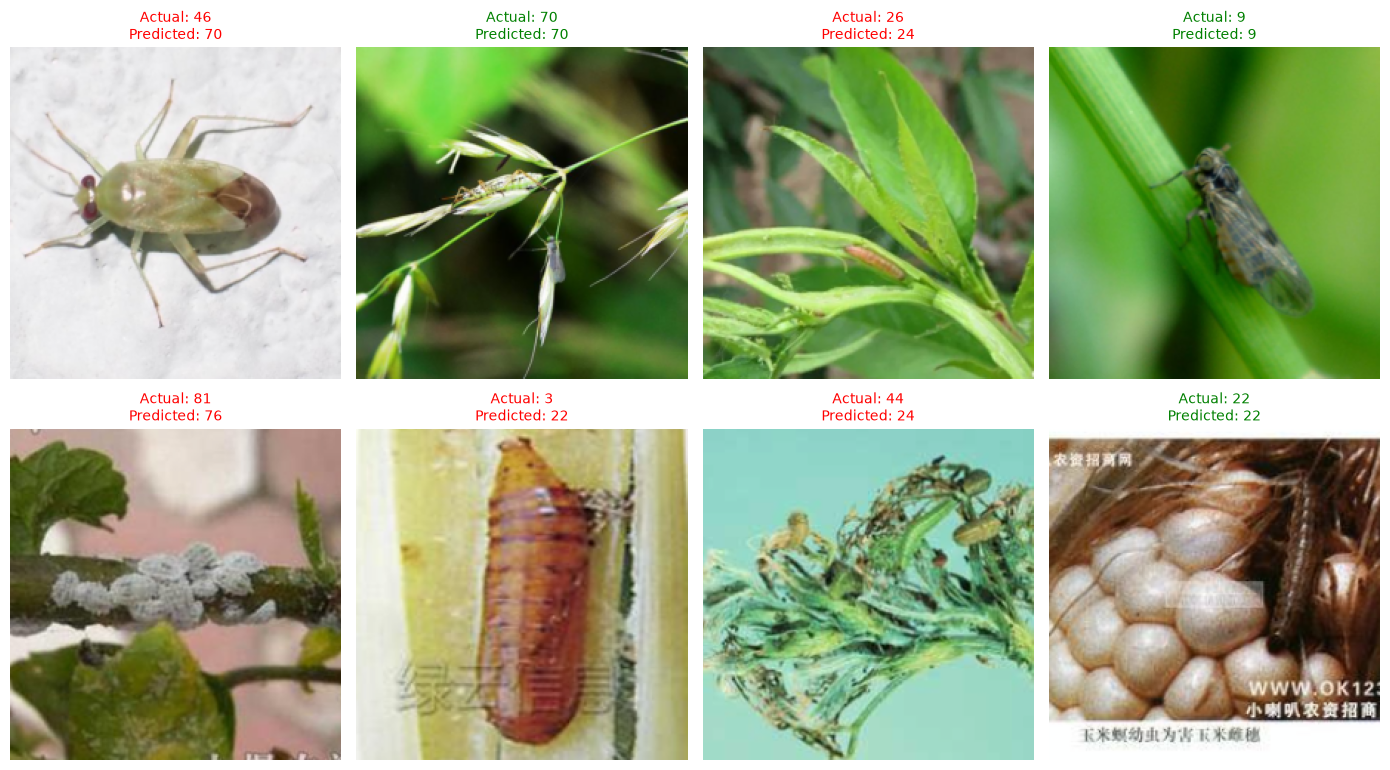

In [ ]:
# Select random test samples
idx = np.random.choice(len(X_test), 8, replace=False)

images = []
labels = []

# Load matching images and labels
for i in idx:
    img, lbl = test_loader.dataset[i]
    images.append(img)
    labels.append(lbl)

images = torch.stack(images).to(device)
labels = torch.tensor(labels)

# Select matching InsecNet extracted features
sample_features = X_test[idx]

# Generate XGBoost predictions
preds = xgb_classifier.predict(sample_features)

# Image statistics for restoring original colors
mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
fig, axs  = plt.subplots(2, 4, figsize=(14, 8))

# Process, un-normalize, and plot each image with its labels
for img_t, lbl, prd, ax in zip(images, labels, preds, axs.ravel()):
    # Convert tensor back to standard RGB image colors
    img = np.clip(std * img_t.cpu().permute(1, 2, 0).numpy() + mean, 0, 1)

    # Display image and label (green = correct, red = wrong)
    ax.imshow(img)
    ax.set_title(f"Actual: {lbl.item()}\nPredicted: {prd}", color="green" if lbl.item() == prd else "red", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## **5. Final Results**
Below is the comparison of model performance across all evaluated classifiers using the chosen metrics:

In [ ]:
results = pd.DataFrame({
    "Model": [
        "SVM",
        "KNN",
        "SVM + KNN",
        "ResNet-50",
        "InsecNet (Scratch)",
        "InsecNet (ImageNet)",
        "InsecNet + SVM",
        "InsecNet + KNN",
        "InsecNet + LR",
        "InsecNet + RF",
        "InsecNet + XGBoost"
    ],
    "Precision": [svm_pre, knn_pre, svm_knn_pre, precision,
                  insec_pre, insec_pre_w, insec_svm_pre, insec_knn_pre, lr_pre, rf_pre, xgb_pre],
    "Recall": [svm_rec, knn_rec, svm_knn_rec, recall,
               insec_rec, insec_rec_w, insec_svm_rec, insec_knn_rec, lr_rec, rf_rec, xgb_rec],
    "F1-score": [svm_f1, knn_f1, svm_knn_f1, f1,
                 insec_f1, insec_f1_w, insec_svm_f1, insec_knn_f1, lr_f1, rf_f1, xgb_f1],
    "G-Mean": [svm_gm, knn_gm, svm_knn_gm, gmean,
               insec_gm, insec_gm_w, insec_svm_gm, insec_knn_gm, lr_gm, rf_gm, xgb_gm],
    "MAUC": [svm_mauc, knn_mauc, svm_knn_mauc, mauc,
             insec_mauc, insec_mauc_w, insec_svm_mauc, insec_knn_mauc, lr_mauc, rf_mauc, xgb_mauc],
    "Accuracy": [svm_acc, knn_acc, svm_knn_acc, accuracy,
                 insec_acc, insec_acc_w, insec_svm_acc, insec_knn_acc, lr_acc, rf_acc, xgb_acc]
})

display(results.style.hide(axis="index").format(precision=4))

## **6. Discussion**